# Comparison Of Decision Trees And Ensemble Models For Mushroom Edibility Classification
## Description:

There are thousands of different species of mushroom, and many of them are inedible and difficult to identify. Here, we aim to find a method to identify edibility by training and examining 3 different machine learning models on the task of classifying whether a mushroom is edible or not based on a set of physical and nonphysical features such as cap dimensions and odor. We are going to use Decision Trees, Adaboost, and Random forest to predict mushroom edibility and then compare the advantages and disadvantages of each model.



## Contribution:

- Xander Boosinger: Initial rough draft, which was largely formatting, cleaning the data of missing values, and applying one-hot-encoding to all non-numeric features (all of them).
- Zach Rojas: Problem discription, feature distribution visualization and analysis, and dataset description.
- Kyle Nguyen: Added a check for constant columns, raw dataset class-balance. Compared encoded dataset shapes across preprocessing versions. Set up helpers or future proofing.


### Part 1: Data Preprocessing

* #### Initial Exploration

The dataset we are using is the UCI Mushroom dataset.  
"Mushroom," UCI Machine Learning Repository, 1981. [Online]. Available: https://doi.org/10.24432/C5959T.

1. Dataset description

In [21]:
#%matplotlib widget
%matplotlib inline 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import pandas as pandas
import seaborn as seaborn
import matplotlib.pyplot as pyplot
import numpy as numpy
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import time

import pandas as pd



#REMEMBER TO UPDATE THIS!
df = pandas.read_csv('../Mushroom/expanded_csv.csv')
df = df.replace('?', numpy.nan)

pandas.set_option('display.max_colwidth', 20)
pandas.set_option('display.width', 1000)
pandas.set_option('display.max_columns', 10)
pandas.set_option('display.max_rows', None)

print("Dimensions:")
print(df.shape)
print("")

print("Info:")
print(df.info())
print("")

print("Describe:")
print(df.describe())
print("")

print("Head:")
print(df.head(5))
print("")



Dimensions:
(8416, 23)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8416 entries, 0 to 8415
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Edibility              8416 non-null   object
 1   CapShape               8416 non-null   object
 2   CapSurface             8416 non-null   object
 3   CapColor               8416 non-null   object
 4   Bruises                8416 non-null   object
 5   Odor                   8416 non-null   object
 6   GillAttachment         8416 non-null   object
 7   GillSpacing            8416 non-null   object
 8   GillSize               8416 non-null   object
 9   GillColor              8416 non-null   object
 10  StalkShape             8416 non-null   object
 11  StalkRoot              5936 non-null   object
 12  StalkSurfaceAboveRing  8416 non-null   object
 13  StalkSurfaceBelowRing  8416 non-null   object
 14  StalkColorAboveRing    8416 non-null   obj

The dataset has 8,416 samples and 23 features with edibility being the target variable. An important characteristic of this dataset is that it is entirely categorical data with no numerical or continuous data, which will affect the preprocessing as we will need to be able to encode the dataset into numerical values.

### Raw Dataset Class Balance

In [22]:
print("Overall Edibility Counts:")
print(df["Edibility"].value_counts())
print()
print("Overall Edibility Proportions:")
print(df["Edibility"].value_counts(normalize=True))

Overall Edibility Counts:
Edibility
EDIBLE       4488
POISONOUS    3928
Name: count, dtype: int64

Overall Edibility Proportions:
Edibility
EDIBLE       0.53327
POISONOUS    0.46673
Name: proportion, dtype: float64


### Feature Distributions

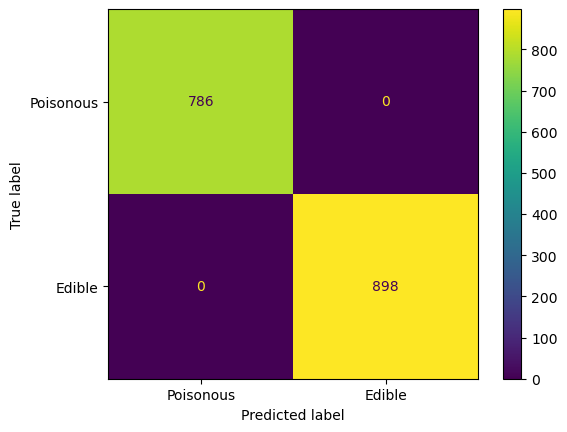

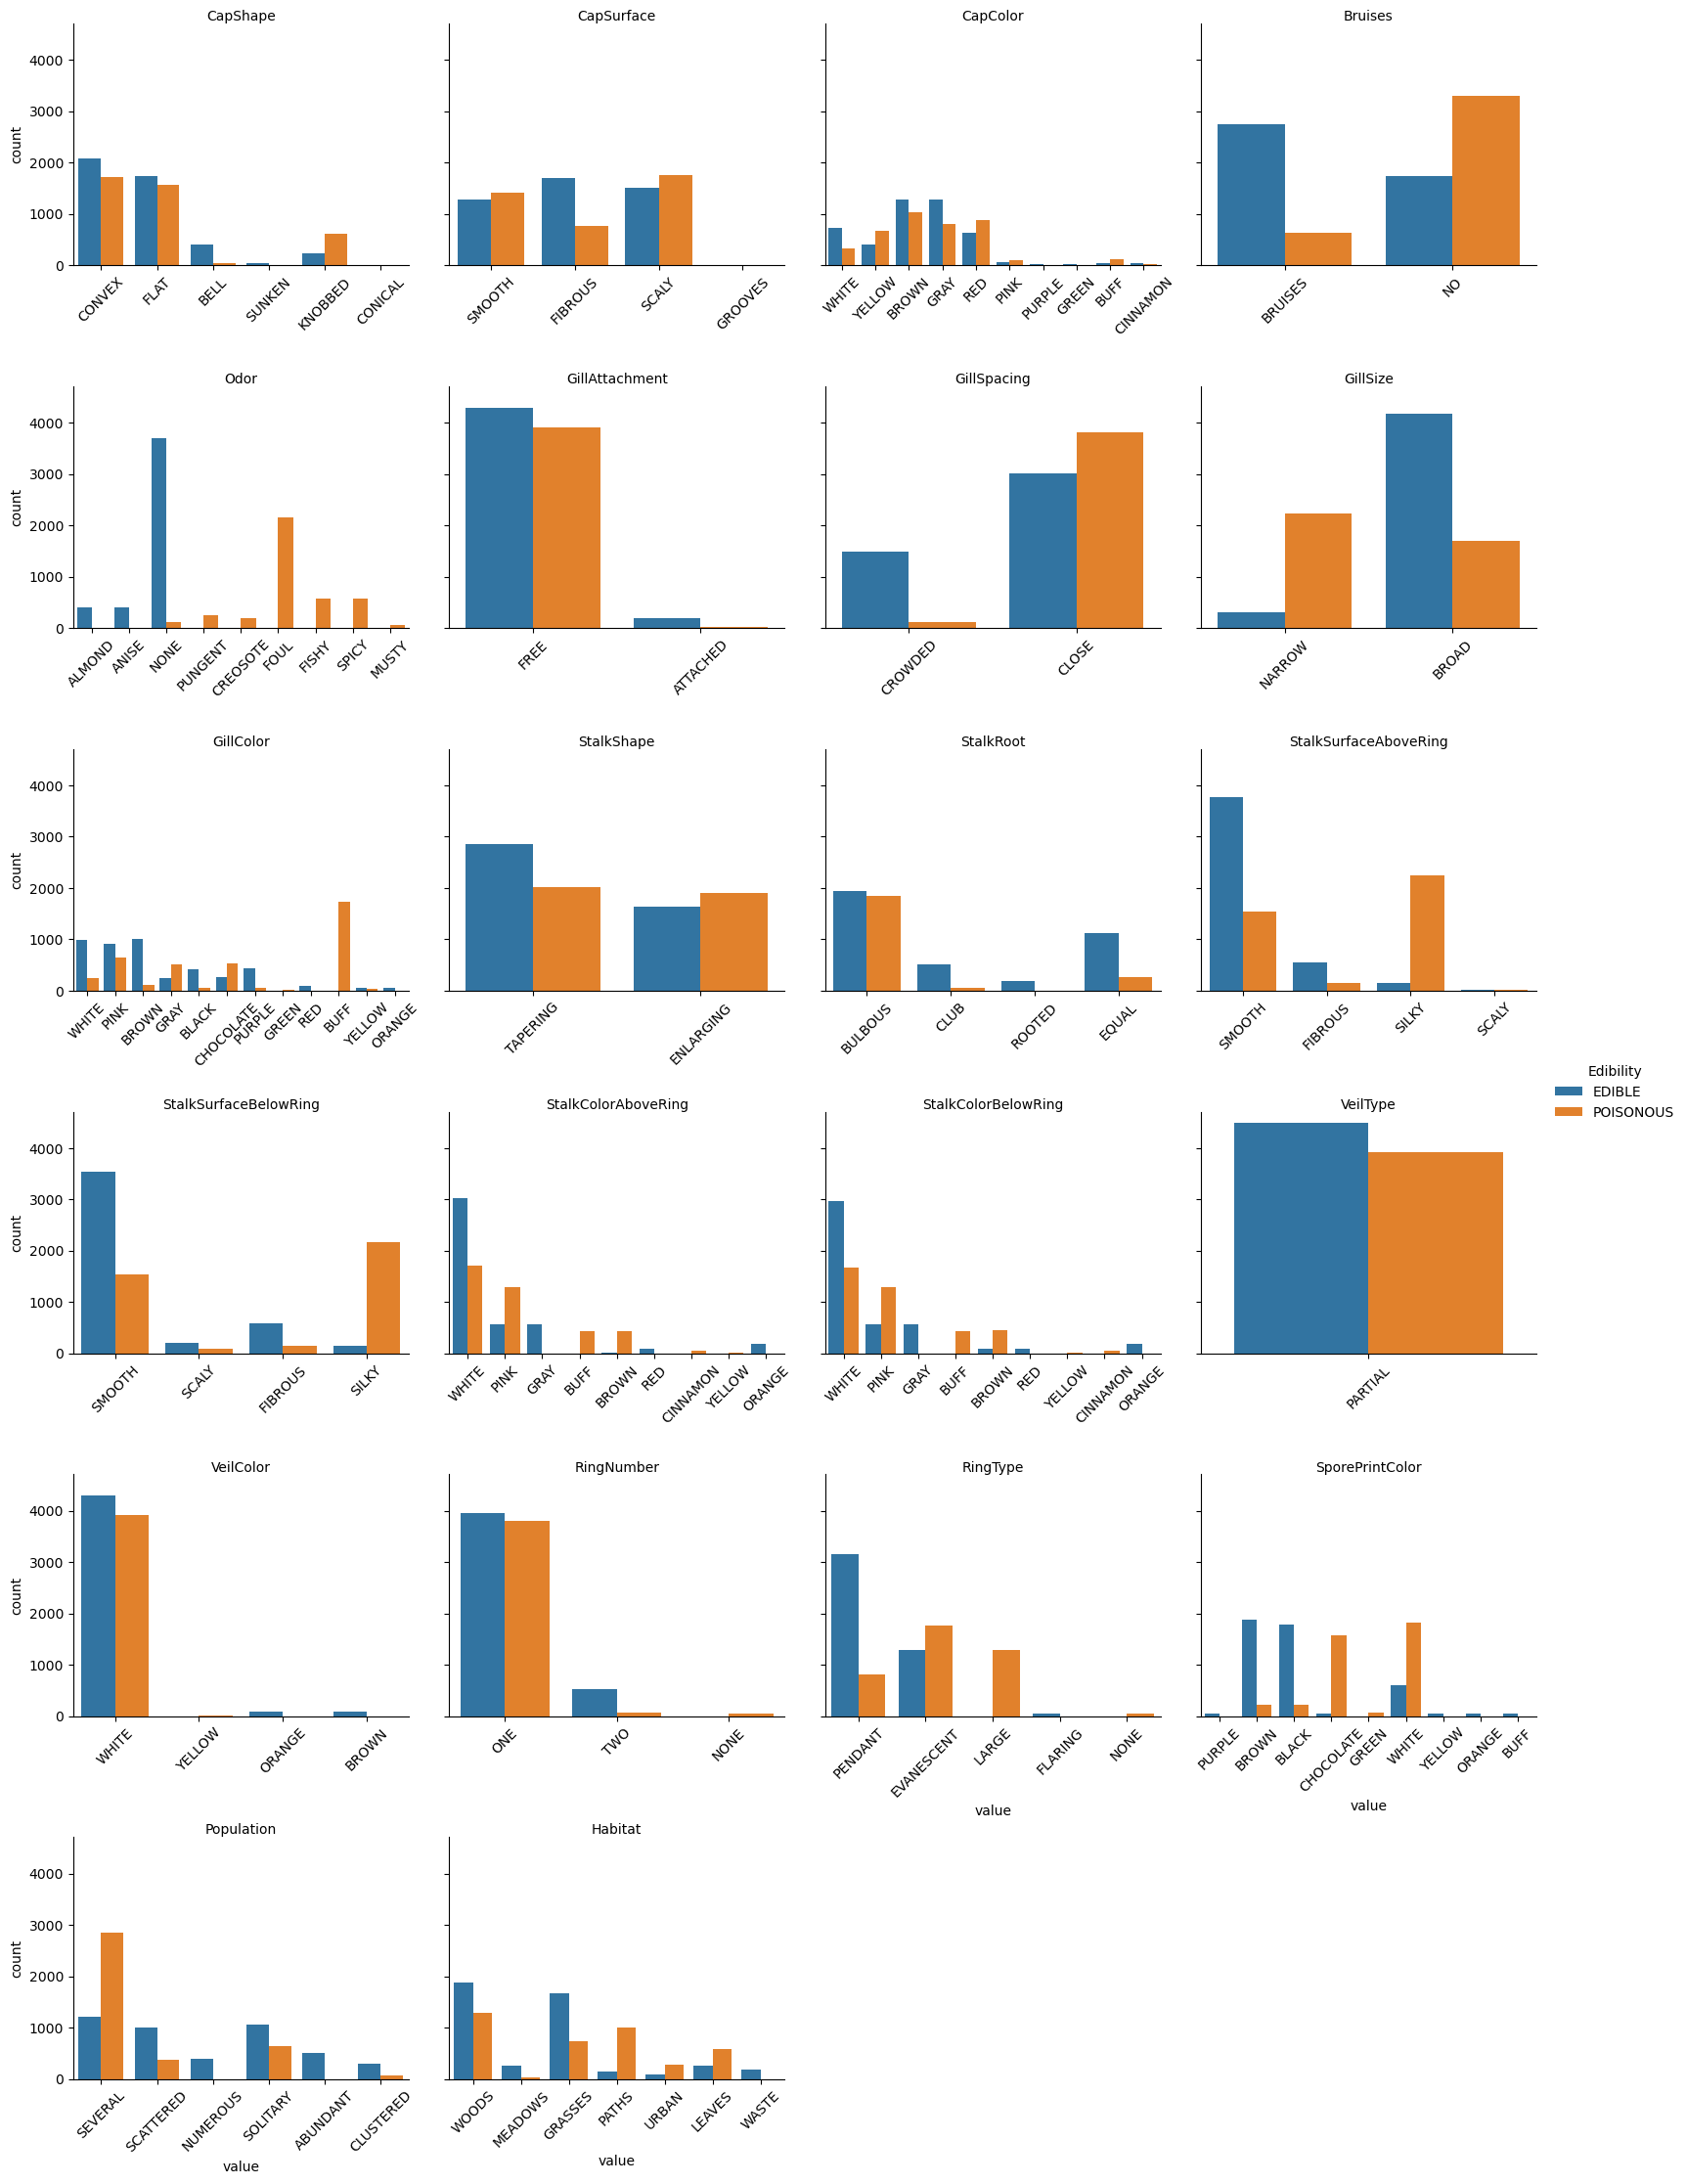

In [23]:

features = df.drop("Edibility", axis=1)

df_melted = df.melt(id_vars='Edibility', value_vars=features.columns)

plot = seaborn.catplot(
    data=df_melted,
    hue='Edibility',
    col='variable',
    kind='count',
    x='value',
    col_wrap=4,
    sharex=False,
    height=4,
)
plot.set_xticklabels(rotation=45)
plot.set_titles("{col_name}", pad=-20)
plot.figure.subplots_adjust(top=0.9, hspace=0.5)

pyplot.show()

Here we can see the distributions of each feature relative to its edibility. For example, for the RingNumber feature, most of the samples have only 1 ring, and there are about an equal number of edible and poisonous mushrooms with one ring. However, mushrooms with two rings are mostly edible. Another insight we can gather from this visualization is based on the odor feature. Mushrooms with an almond, anise, or no odor, are almost entirely edible, while mushrooms with other odors are mostly poisonous. We can see similar patterns across other features as well, such as with the Bruizes, StalkSurfaceAboveRing, GillColor, GillSize and RingType features, which have some of the largest differences in ratios of edible and poisonous based on the value of these features. 

2. Check for missing values in every column.

In [24]:
print("Null Value Counts:")
print(df.isnull().sum())
print("")

Null Value Counts:
Edibility                   0
CapShape                    0
CapSurface                  0
CapColor                    0
Bruises                     0
Odor                        0
GillAttachment              0
GillSpacing                 0
GillSize                    0
GillColor                   0
StalkShape                  0
StalkRoot                2480
StalkSurfaceAboveRing       0
StalkSurfaceBelowRing       0
StalkColorAboveRing         0
StalkColorBelowRing         0
VeilType                    0
VeilColor                   0
RingNumber                  0
RingType                    0
SporePrintColor             0
Population                  0
Habitat                     0
dtype: int64



3. For each column that has missing values, decide how to handle it.

In [25]:
dfnullsdropped = df.drop(["StalkRoot"], axis=1)
dfnullsfilled = df.copy()
dfnullsfilled.fillna({"StalkRoot": "UNKNOWN"}, inplace=True)

To help analyze the impact of different preprocessing strategies, We are making multiple versions of the dataset; dfnullsdropped for dropping the features with missing values wholesale, and dfnullsfilled for replacing the null values with a new "unknown" value for the features in question. In this case, the only feature which has missing values is StalkRoot. Additionally, removing the records with missing values isn't a viable option at all, because we'd be losing a quarter of the dataset despite only about 1% of the overall data missing.

In [26]:
print("Unique values per raw feature:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values -> {sorted(df[col].dropna().unique())}")

Unique values per raw feature:
Edibility: 2 unique values -> ['EDIBLE', 'POISONOUS']
CapShape: 6 unique values -> ['BELL', 'CONICAL', 'CONVEX', 'FLAT', 'KNOBBED', 'SUNKEN']
CapSurface: 4 unique values -> ['FIBROUS', 'GROOVES', 'SCALY', 'SMOOTH']
CapColor: 10 unique values -> ['BROWN', 'BUFF', 'CINNAMON', 'GRAY', 'GREEN', 'PINK', 'PURPLE', 'RED', 'WHITE', 'YELLOW']
Bruises: 2 unique values -> ['BRUISES', 'NO']
Odor: 9 unique values -> ['ALMOND', 'ANISE', 'CREOSOTE', 'FISHY', 'FOUL', 'MUSTY', 'NONE', 'PUNGENT', 'SPICY']
GillAttachment: 2 unique values -> ['ATTACHED', 'FREE']
GillSpacing: 2 unique values -> ['CLOSE', 'CROWDED']
GillSize: 2 unique values -> ['BROAD', 'NARROW']
GillColor: 12 unique values -> ['BLACK', 'BROWN', 'BUFF', 'CHOCOLATE', 'GRAY', 'GREEN', 'ORANGE', 'PINK', 'PURPLE', 'RED', 'WHITE', 'YELLOW']
StalkShape: 2 unique values -> ['ENLARGING', 'TAPERING']
StalkRoot: 4 unique values -> ['BULBOUS', 'CLUB', 'EQUAL', 'ROOTED']
StalkSurfaceAboveRing: 4 unique values -> ['FIBROU

4. Verify that no missing values remain.

In [27]:
print("Null Value Counts:")
print(dfnullsdropped.isnull().sum())
print("")
print(dfnullsdropped.shape)
print("")
print(dfnullsfilled.isnull().sum())
print("")
print(dfnullsfilled.shape)
print("")

Null Value Counts:
Edibility                0
CapShape                 0
CapSurface               0
CapColor                 0
Bruises                  0
Odor                     0
GillAttachment           0
GillSpacing              0
GillSize                 0
GillColor                0
StalkShape               0
StalkSurfaceAboveRing    0
StalkSurfaceBelowRing    0
StalkColorAboveRing      0
StalkColorBelowRing      0
VeilType                 0
VeilColor                0
RingNumber               0
RingType                 0
SporePrintColor          0
Population               0
Habitat                  0
dtype: int64

(8416, 22)

Edibility                0
CapShape                 0
CapSurface               0
CapColor                 0
Bruises                  0
Odor                     0
GillAttachment           0
GillSpacing              0
GillSize                 0
GillColor                0
StalkShape               0
StalkRoot                0
StalkSurfaceAboveRing    0
StalkSurfa

* #### Encode Categorical Features 
1.  Identify the string columns that can be meaningfully encoded. Apply the 
appropriate encoding method to each: 
    1) Binary columns with exactly two values to convert to 0/1.
    2) Columns with more than two categories to create one-hot encoded columns. 

In [28]:
#From Stack Overflow https://stackoverflow.com/questions/67221853/how-do-i-exclude-a-column-from-pandas-pd-get-dummies
columns_to_exclude = ['Bruises', 'GillSize', 'StalkShape', 'VeilType', 'RingNumber', 'Edibility']

#make a copy
dfnullsdropped = dfnullsdropped.copy()
dfnullsfilled = dfnullsfilled.copy()



dfnullsdropped = pandas.get_dummies(dfnullsdropped, columns=list(filter(
    lambda i: i not in columns_to_exclude,
    dfnullsdropped.columns)), dtype=int)
dfnullsfilled = pandas.get_dummies(dfnullsfilled, columns=list(filter(
    lambda i: i not in columns_to_exclude,
    dfnullsfilled.columns)), dtype=int)

dfnullsdropped.loc[:, "Bruises"] = dfnullsdropped["Bruises"].replace(["NO", "BRUISES"], [0, 1]).astype(int)
dfnullsdropped.loc[:, "GillSize"] = dfnullsdropped["GillSize"].replace(["NARROW", "BROAD"],[0, 1]).astype(int)
dfnullsdropped.loc[:, "StalkShape"] = dfnullsdropped["StalkShape"].replace(["TAPERING", "ENLARGING"], [0, 1]).astype(int)
dfnullsdropped.loc[:, "VeilType"] = dfnullsdropped["VeilType"].replace(["PARTIAL", "UNIVERSAL"], [0, 1]).astype(int)#No UNIVERSAL examples???
dfnullsdropped.loc[:, "RingNumber"] = dfnullsdropped["RingNumber"].replace(["NONE", "ONE", "TWO"], [0, 1, 2]).astype(int)
dfnullsdropped.loc[:, "Edibility"] = dfnullsdropped["Edibility"].replace(["POISONOUS", "EDIBLE"], [0, 1]).astype(int)

dfnullsfilled.loc[:, "Bruises"] = dfnullsfilled["Bruises"].replace(["NO", "BRUISES"], [0, 1]).astype(int)
dfnullsfilled.loc[:, "GillSize"] = dfnullsfilled["GillSize"].replace(["NARROW", "BROAD"], [0, 1]).astype(int)
dfnullsfilled.loc[:, "StalkShape"] = dfnullsfilled["StalkShape"].replace(["TAPERING", "ENLARGING"], [0, 1]).astype(int)
dfnullsfilled.loc[:, "VeilType"] = dfnullsfilled["VeilType"].replace(["PARTIAL", "UNIVERSAL"], [0, 1]).astype(int)#No UNIVERSAL examples???
dfnullsfilled.loc[:, "RingNumber"] = dfnullsfilled["RingNumber"].replace(["NONE", "ONE", "TWO"], [0, 1, 2]).astype(int)
dfnullsfilled.loc[:, "Edibility"] = dfnullsfilled["Edibility"].replace(["POISONOUS", "EDIBLE"], [0, 1]).astype(int)

print("Dropped")
print(dfnullsdropped.head())
print("")
print("Filled")
print(dfnullsfilled.head())
print("")

Dropped
  Edibility Bruises GillSize StalkShape VeilType  ... Habitat_MEADOWS  Habitat_PATHS  Habitat_URBAN  Habitat_WASTE  Habitat_WOODS
0         1       1        0          0        0  ...               0              0              0              0              1
1         1       1        0          0        0  ...               0              0              0              0              1
2         1       1        0          0        0  ...               0              0              0              0              1
3         1       1        0          0        0  ...               0              0              0              0              1
4         1       1        0          0        0  ...               0              0              0              0              1

[5 rows x 108 columns]

Filled
  Edibility Bruises GillSize StalkShape VeilType  ... Habitat_MEADOWS  Habitat_PATHS  Habitat_URBAN  Habitat_WASTE  Habitat_WOODS
0         1       1        0          0        0  

In [29]:
print("Constant columns:")
for col in df.columns:
    if df[col].nunique(dropna=False) == 1:
        print(col)

Constant columns:
VeilType


GillAttachment and GillSpacing have been One-Hot-Encoded despite only having two values in the dataset because the UCI dataset description lists these features as having more options, so I'm choosing to respect that, in case additional data is found at some point in the future.

There are no records of any mushrooms with UNIVERSAL VeilType, nor any with NONE RingNumber. RingNumber will be treated as a continuous numerical value.

3. Drop the columns that cannot be meaningfully encoded. 

In [30]:
#Nothing

All of the columns have been prepared, and none were deemed unmeaningful.

### Compare Feature Counts after encoding between the two version


In [31]:
print("Encoded dataset shapes:")
print("Dropped version:", dfnullsdropped.shape)
print("Filled version:", dfnullsfilled.shape)

Encoded dataset shapes:
Dropped version: (8416, 108)
Filled version: (8416, 113)


* #### Heatmap Visualization 
1.  Generate a correlation heatmap for all features in your DataFrame.

Heatmap Correlation
NullsDropped


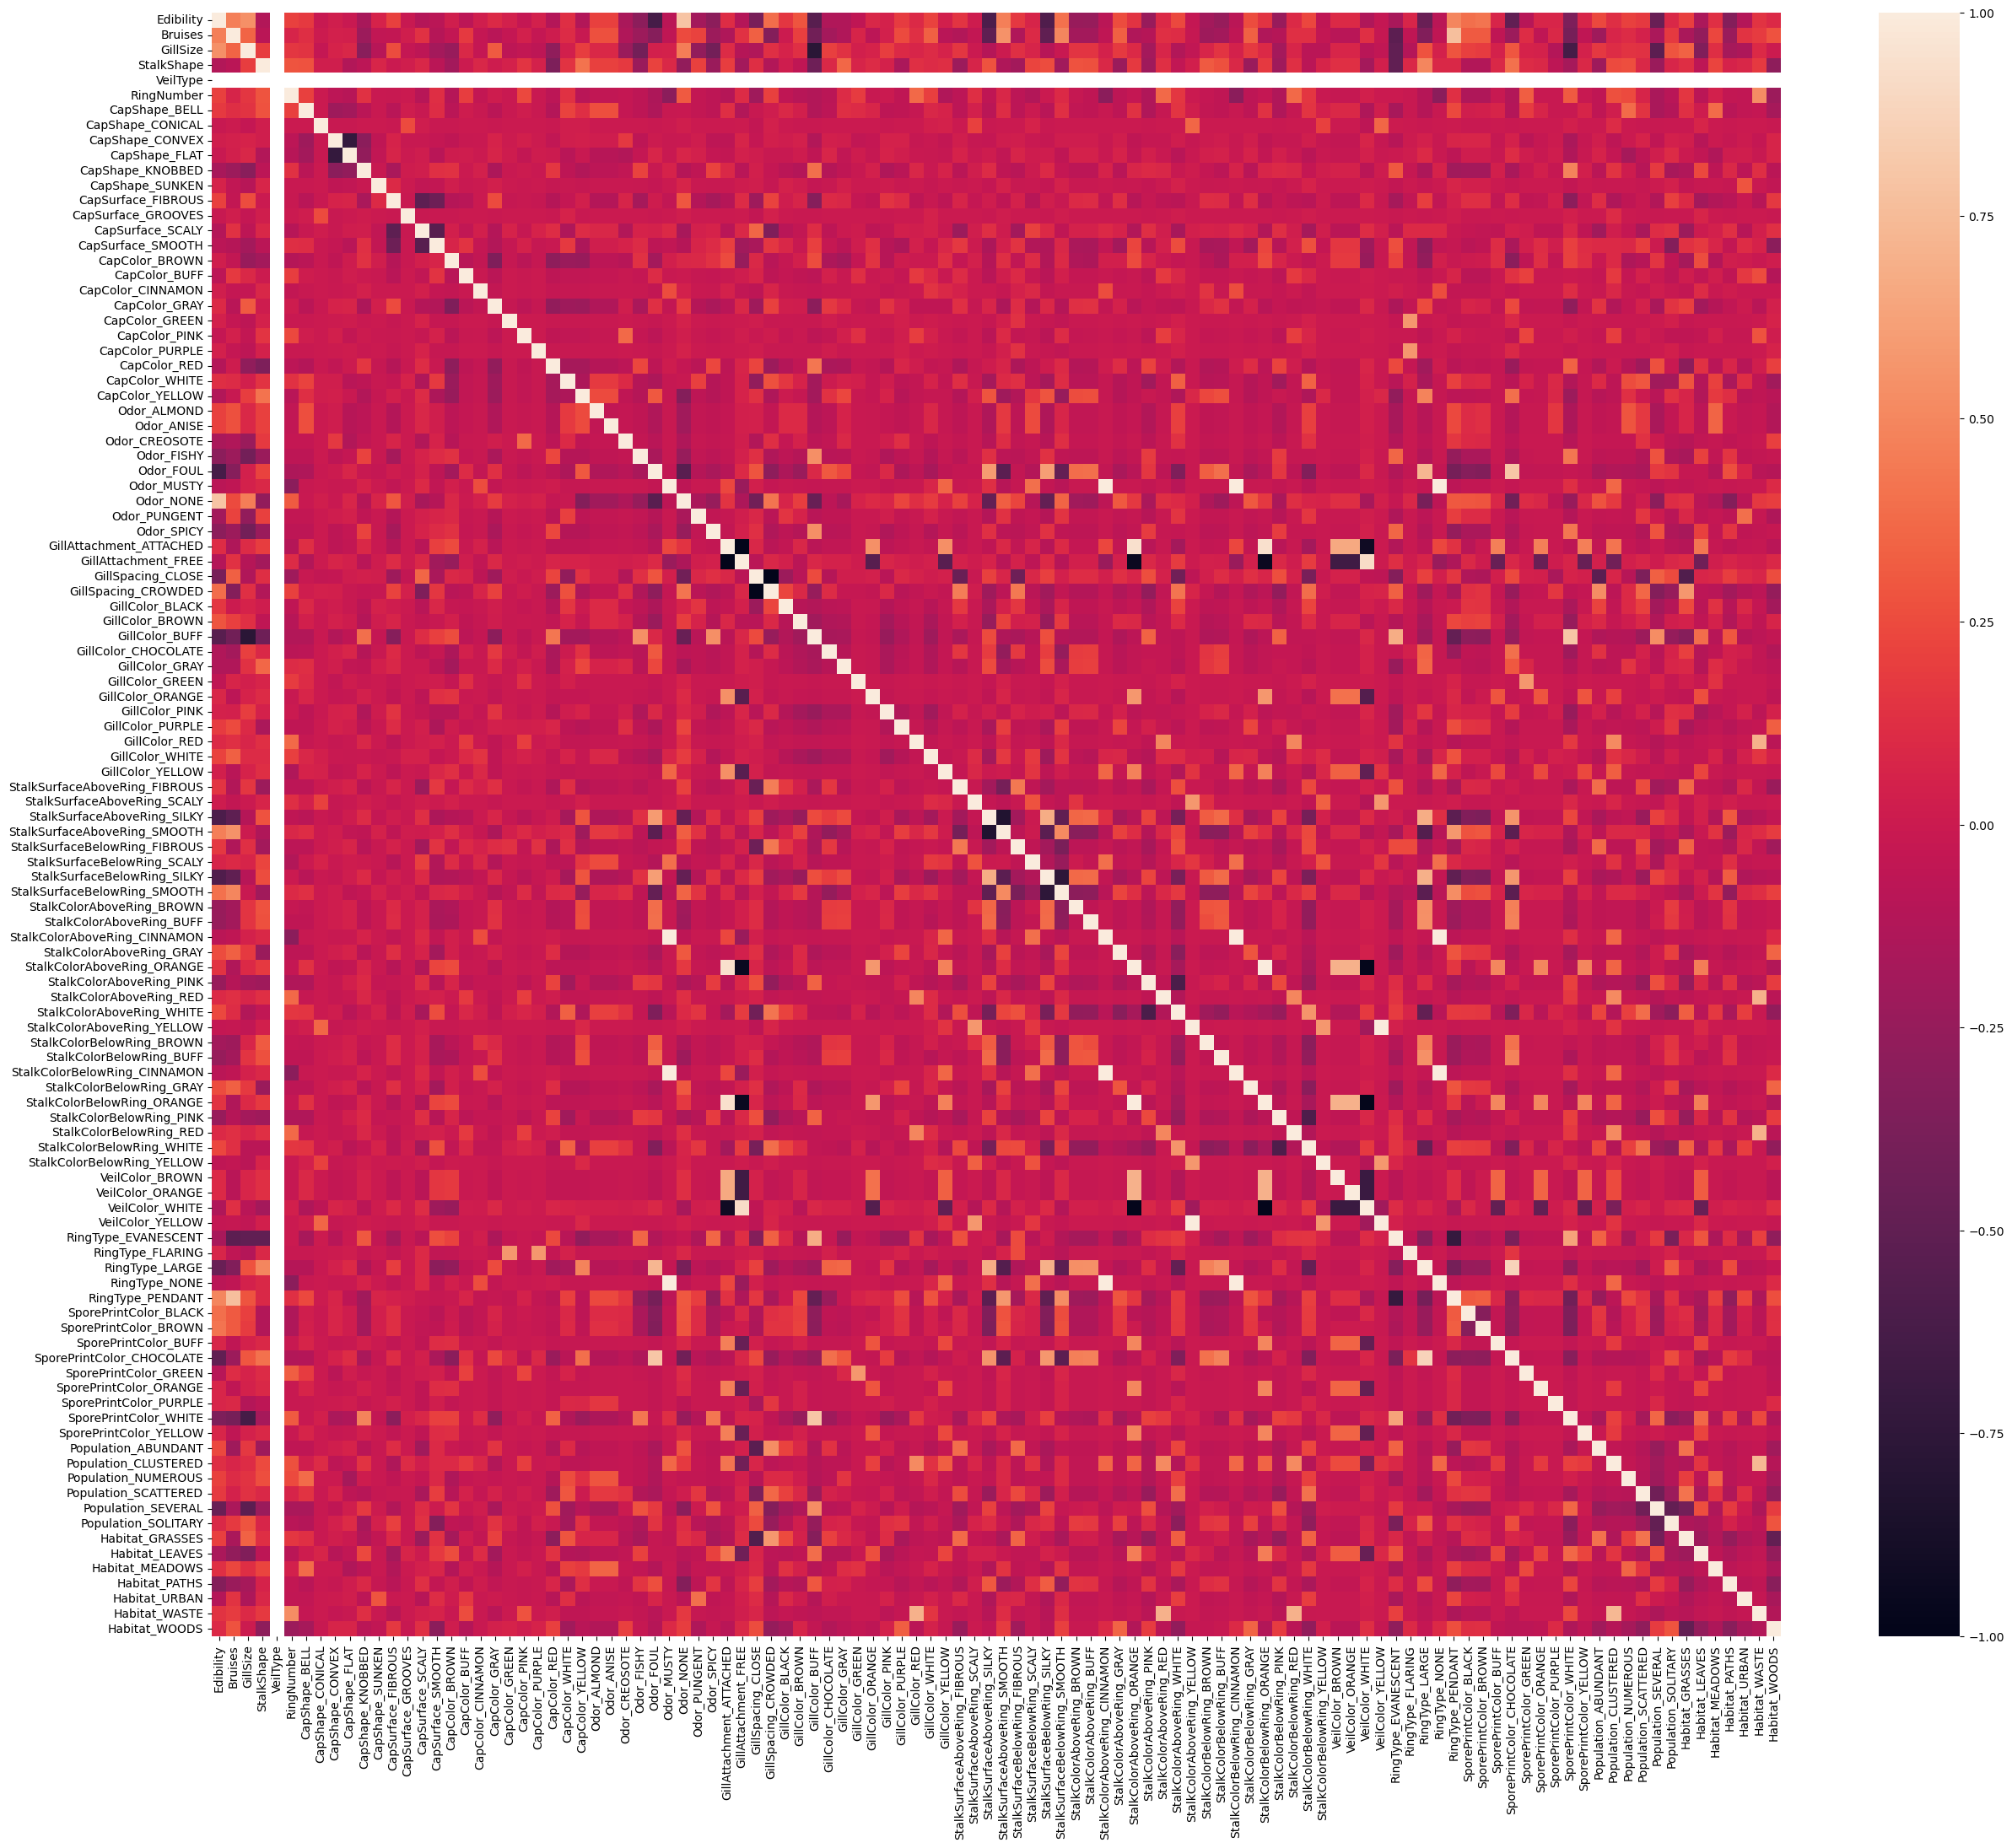


ModeImputed


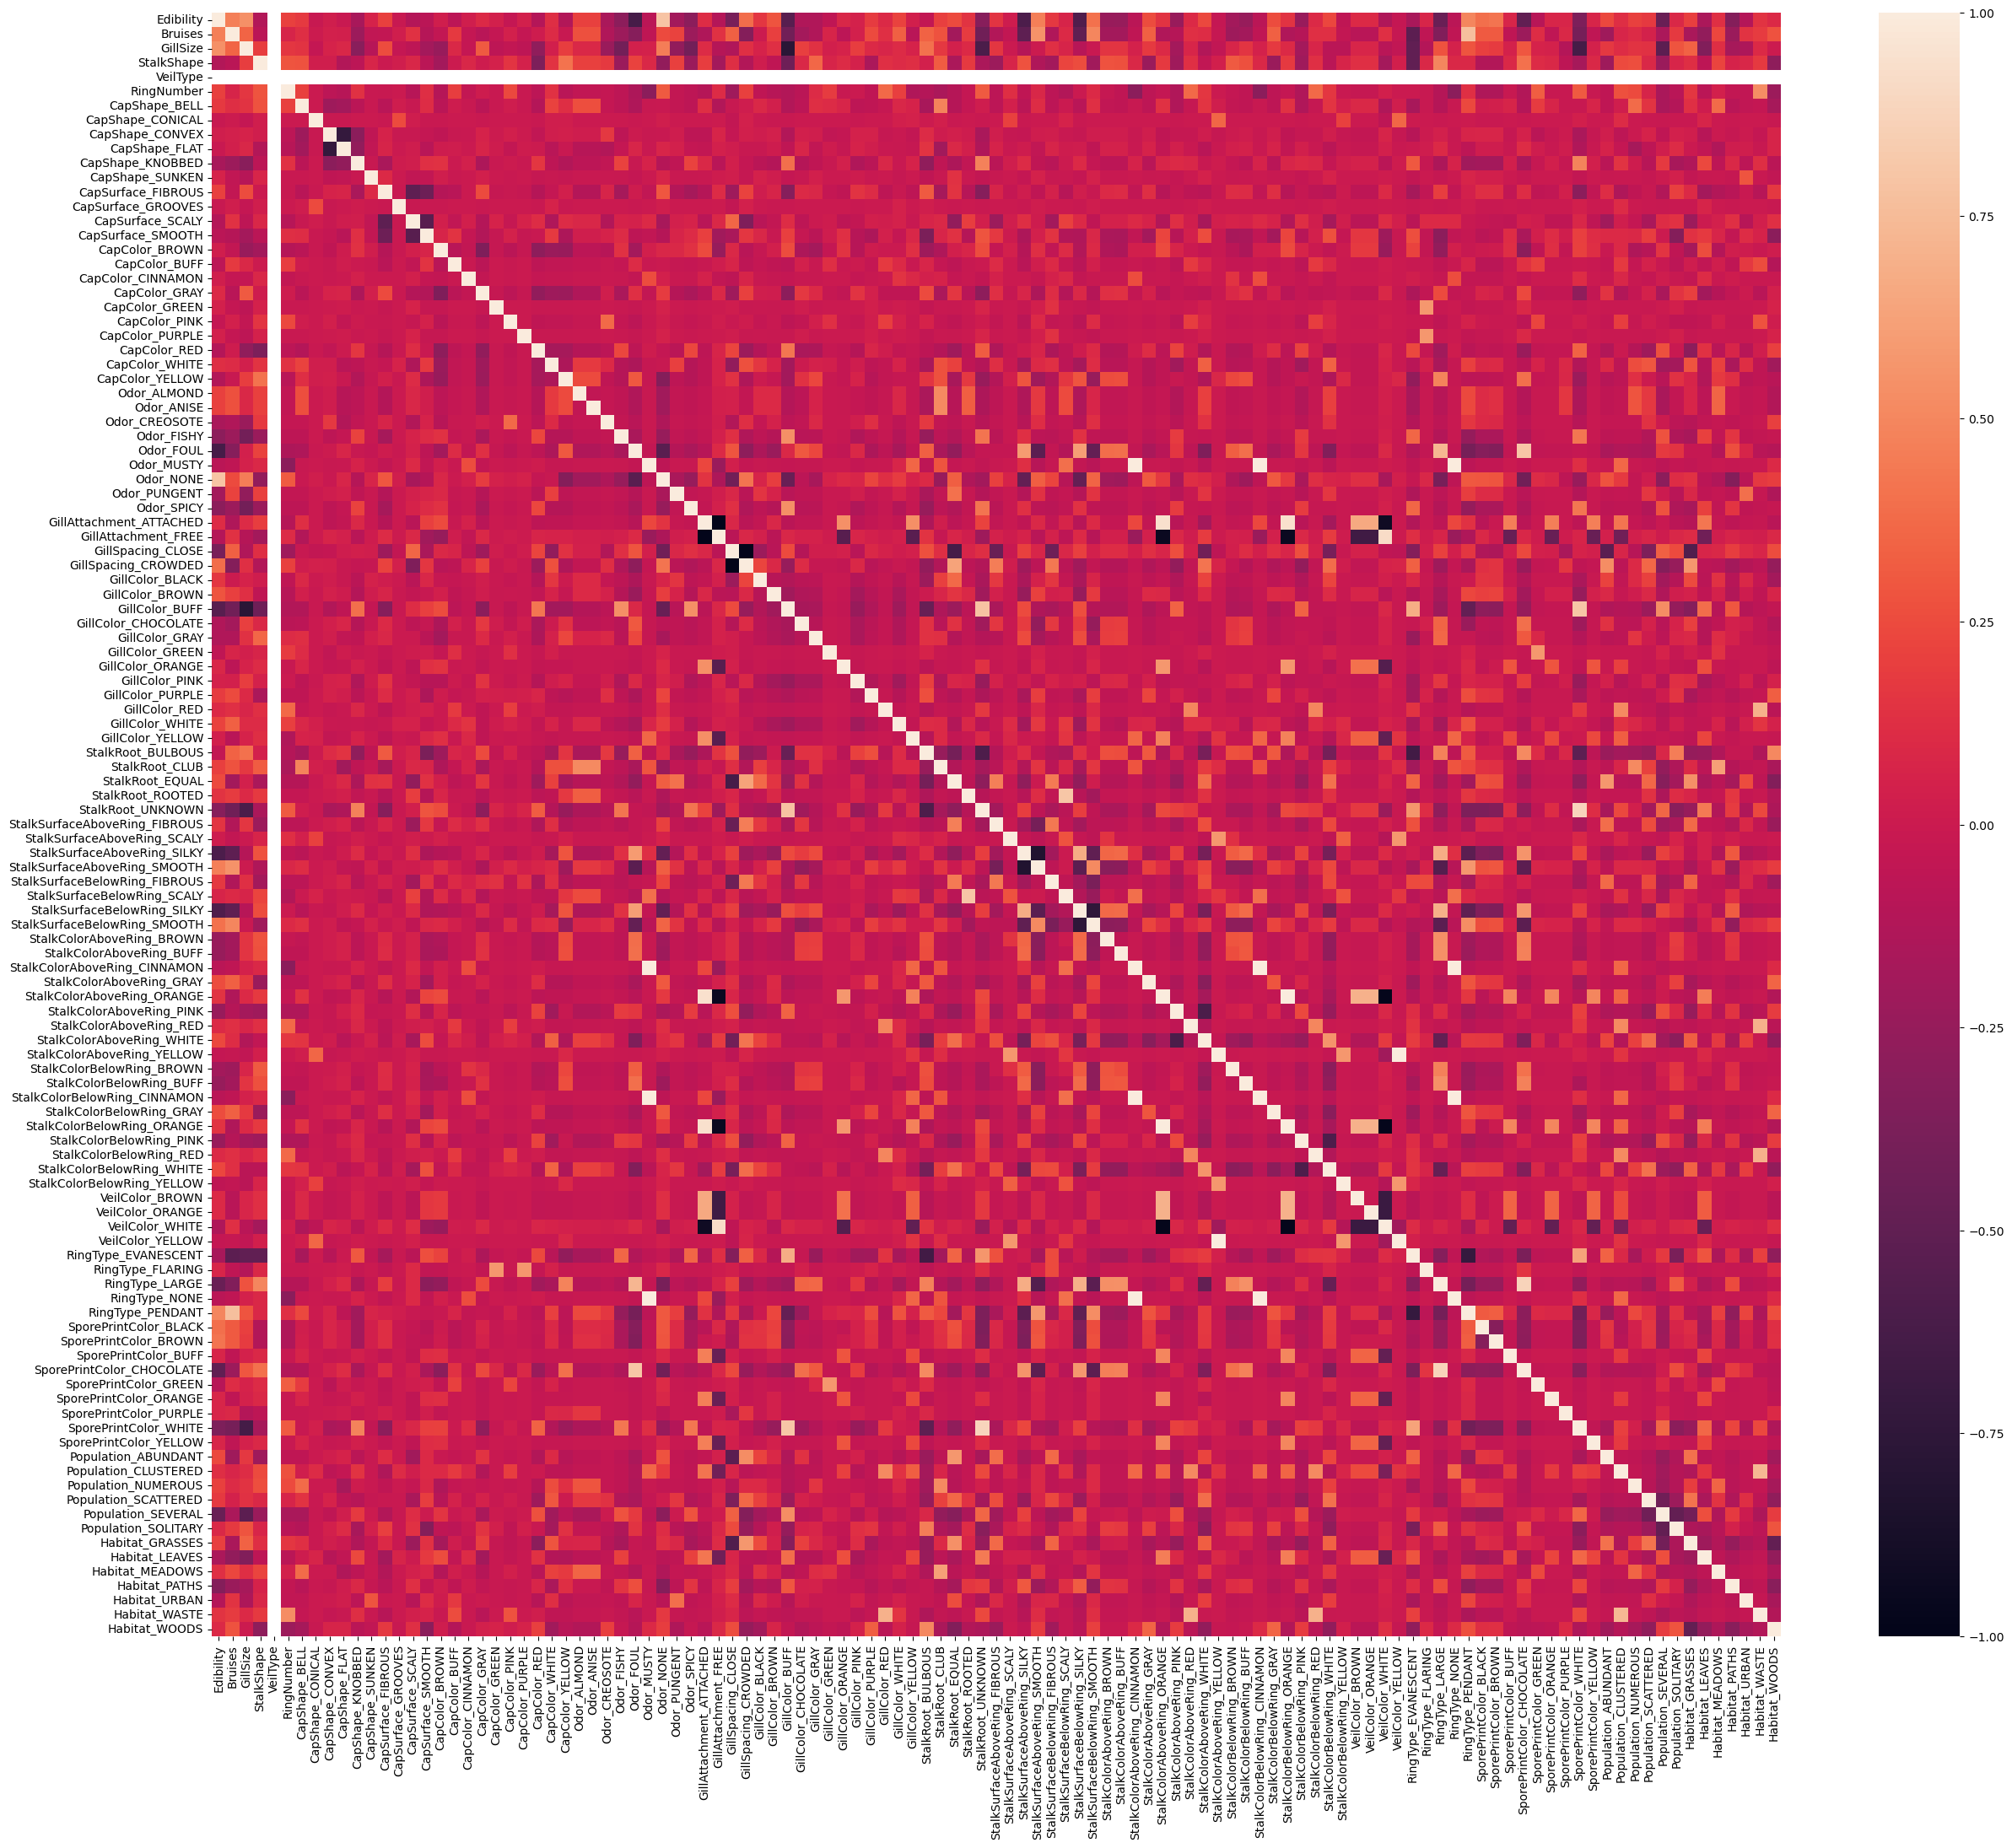

In [32]:
print("Heatmap Correlation")
print("NullsDropped")
pyplot.figure(figsize=(30, 25))
correlationMatrix = dfnullsdropped.corr()
seaborn.heatmap(correlationMatrix, annot=False)#Don't annotate because there's too many numbers for them to be meaningful individually.
pyplot.show()
print("")
print("ModeImputed")
pyplot.figure(figsize=(30, 25))
correlationMatrix = dfnullsfilled.corr()
seaborn.heatmap(correlationMatrix, annot=False)#Same thing here.
pyplot.show()
print("")

The heatmaps are relatively humongous, due to all the one-hot-encoding columns we've added; the amount of data here is too much for me to properly analyze closely, but I can express a few big picture insights.

One, the overall heatmap is very 0.0 correlation red; I expect this is a good sign, as low correlation means each feature is encoding different information to the others.

It also appears that many of the correlation spikes, as one might expect, are referring to the one-hot-encoding groups, clustered around the central diagonal line. However, there are also notable correlation spikes around the StalkSurfaceBelowRing x SporePrintColor and VeilColor x GillAttachment groupings, which may be of note later on or if we wanted to choose features to drop from the dataset.

Finally, one row of particular note is of course "Edibility". The features with the highest absolute correlation values were: Bruises, GillSize, Odor_FOUL, Odor_NONE, GillSpacing_CROWDED, GillColor_BROWN, GillColor_BUFF, StalkSurfaceAboveRing_SILKY, StalkSurfaceAboveRing_SMOOTH, StalkSurfaceBelowRing_SILKY, StalkSurfaceBelowRing_SMOOTH, RingType_LARGE, RingType_PENDANT, SporePrintColor_BLACK, SporePrintColor_BROWN, SporePrintColor_CHOCOLATE, SporePrintColor_WHITE, Population_SEVERAL, Habitat_PATHS. These features are the ones that are therefore most likely to be the most helpful in determining edibility; whether a mushroom has an Odor of FOUL or an odor of NONE correlates very strongly to a mushroom's edibility, thereby making Odor a very important feature for determining as much.

Of these, it is of note that several appear in the list of the six features listed as most important by https://www.mecs-press.org/ijigsp/ijigsp-v11-n4/IJIGSP-V11-N4-5.pdf, though not all. In particular, CapColor doesn't seem to have any particularly strong correlations based on this heatmap, which does disagree with the above research paper's assertion.

* #### Prepare Features and Split 
1.  Split your data into training and testing sets, using stratification.

In [33]:
droppedfeatures = dfnullsdropped.drop(columns=["Edibility"])
droppedlabels = dfnullsdropped["Edibility"].astype(int)

#Split the data into training and testing feature tables, and training and testing label arrays
droppedfeatures_train, droppedfeatures_test, droppedlabels_train, droppedlabels_test = train_test_split(
    droppedfeatures,
    droppedlabels,
    test_size=0.2,
    random_state=42,
    stratify=droppedlabels
)



filledfeatures = dfnullsfilled.drop(columns=["Edibility"])
filledlabels = dfnullsfilled["Edibility"].astype(int)

#Split the data into training and testing feature tables, and training and testing label arrays
filledfeatures_train, filledfeatures_test, filledlabels_train, filledlabels_test = train_test_split(
    filledfeatures,
    filledlabels,
    test_size=0.2,
    random_state=42,
    stratify=filledlabels
)

2. Print the shape of all four arrays (X_train, X_test, y_train, y_test). 

In [34]:
print("Split Data:")
print("Dropped")
print(droppedfeatures_train.shape)
print(droppedfeatures_test.shape)
print(droppedlabels_train.shape)
print(droppedlabels_test.shape)
print("")
print("Imputed")
print(filledfeatures_train.shape)
print(filledfeatures_test.shape)
print(filledlabels_train.shape)
print(filledlabels_test.shape)
print("")

Split Data:
Dropped
(6732, 107)
(1684, 107)
(6732,)
(1684,)

Imputed
(6732, 112)
(1684, 112)
(6732,)
(1684,)



3. In a markdown cell, verify that the survival rate is approximately the same in
both splits.

In [35]:
print("Value Counts:")
print("")
print("Dropped")
print(droppedlabels_train.value_counts())
print("Edibility Ratio:", droppedlabels_train.value_counts()[1] /  droppedlabels_train.value_counts()[0])
print(droppedlabels_test.value_counts())
print("Edibility Ratio:", droppedlabels_test.value_counts()[1] /  droppedlabels_test.value_counts()[0])
print("")
print("Imputed")
print(filledlabels_train.value_counts())
print("Edibility Ratio:", filledlabels_train.value_counts()[1] /  filledlabels_train.value_counts()[0])
print(filledlabels_test.value_counts())
print("Edibility Ratio:", filledlabels_test.value_counts()[1] /  filledlabels_test.value_counts()[0])
print("")

Value Counts:

Dropped
Edibility
1    3590
0    3142
Name: count, dtype: int64
Edibility Ratio: 1.1425843411839594
Edibility
1    898
0    786
Name: count, dtype: int64
Edibility Ratio: 1.1424936386768447

Imputed
Edibility
1    3590
0    3142
Name: count, dtype: int64
Edibility Ratio: 1.1425843411839594
Edibility
1    898
0    786
Name: count, dtype: int64
Edibility Ratio: 1.1424936386768447



The survival ratio is effectively the same for both sets, so the stratification worked nicely.

4. Verify that all features are numerical by printing X_train.dtypes. In a 
markdown cell, confirm that no string or Boolean columns remain. If any do, fix them 
now and explain what you have changed. 

In [36]:
print("Types:")
print("Dropped")
print(droppedfeatures_train.dtypes)
print("")
print(droppedfeatures_test.dtypes)
print("")
print(droppedlabels_train.head())
print("")
print(droppedlabels_test.head())
print("")
print("Imputed")
print(filledfeatures_train.dtypes)
print("")
print(filledfeatures_test.dtypes)
print("")
print(filledlabels_train.head())
print("")
print(filledlabels_test.head())
print("")

Types:
Dropped
Bruises                          object
GillSize                         object
StalkShape                       object
VeilType                         object
RingNumber                       object
CapShape_BELL                     int32
CapShape_CONICAL                  int32
CapShape_CONVEX                   int32
CapShape_FLAT                     int32
CapShape_KNOBBED                  int32
CapShape_SUNKEN                   int32
CapSurface_FIBROUS                int32
CapSurface_GROOVES                int32
CapSurface_SCALY                  int32
CapSurface_SMOOTH                 int32
CapColor_BROWN                    int32
CapColor_BUFF                     int32
CapColor_CINNAMON                 int32
CapColor_GRAY                     int32
CapColor_GREEN                    int32
CapColor_PINK                     int32
CapColor_PURPLE                   int32
CapColor_RED                      int32
CapColor_WHITE                    int32
CapColor_YELLOW          

As can be seen above, all of the columns remaining are int64 types, as intended.

### HELPERS




In [37]:

#result table for future proof
results = pd.DataFrame(columns=[
    "Model",
    "Preprocessing",
    "Hyperparameters",
    "CV Mean",
    "CV Std",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1",
    "Training Time (s)",
    "Notes"
])

results


#Function to add results to the results DataFrame
def add_result(results_df, model_name, preprocessing_name, hyperparameters,
               cv_mean, cv_std, test_accuracy, test_precision,
               test_recall, test_f1, training_time, notes=""):
    
    results_df.loc[len(results_df)] = {
        "Model": model_name,
        "Preprocessing": preprocessing_name,
        "Hyperparameters": str(hyperparameters),
        "CV Mean": cv_mean,
        "CV Std": cv_std,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1,
        "Training Time (s)": training_time,
        "Notes": notes
    }
    
    return results_df


#Function to evaluate a model and return the relevant metrics
def evaluate_model(model, X_train, X_test, y_train, y_test):
    start_time = time.time()
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    training_time = time.time() - start_time
    
    results = {
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),
        "Training Time (s)": training_time
    }
    
    return results, y_pred



def plot_adaboost_models_scores(xrange, adamodels, accuracydata, precisiondata, recalldata, timedata, yrange = [0.97, 1.01]):
    pyplot.xlim(min(xrange), max(xrange))
    pyplot.ylim(yrange[0], yrange[1])
    
    pyplot.plot(accuracydata, label='Accuracy')
    pyplot.plot(precisiondata, label='Precision')
    pyplot.plot(recalldata, label='Recall')
    pyplot.legend()
    #pyplot.minorticks_on()
    pyplot.grid(which='both')
    
    maxadaaccuracy = max(accuracydata)
    maxadaaccuracyindex = accuracydata.index(maxadaaccuracy)
    bestadamodel = adamodels[maxadaaccuracyindex - 1]
    
    pyplot.plot(
        maxadaaccuracyindex,
        maxadaaccuracy,
        "o",
        color="red",
        label=f'Max Acc. = {maxadaaccuracy:.5f}'
    )
    
    pyplot.title('Scores By N')
    pyplot.xlabel('N (Tens)')
    pyplot.ylabel('Mean Score')
    pyplot.legend()
    
    pyplot.show()
    
    
    
    pyplot.xlim(min(xrange), max(xrange))
    pyplot.plot(timedata, label='Training Time')
    pyplot.grid(which='both')
    pyplot.legend()
    
    pyplot.title('Training Times By N')
    pyplot.xlabel('N (Tens)')
    pyplot.ylabel('Time (s)')
    
    pyplot.show()

    return bestadamodel

## Model Implementation

### Decision Tree

We chose the decision tree as one of our models to compare because of the nature of the dataset. Because the dataset is entirely continuous values, a decision tree should handle the data well and be a good baseline for comparing with the other 2 models. Additionally, a decision tree would be useful for this problem because of its interpretability. Given the real world context of classifying if a mushroom is safe to eat, being able to understand how the model made its decision is important. 

Creating a baseline model

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

decision_tree_results = pd.DataFrame(columns=[
    "Model",
    "Preprocessing",
    "Hyperparameters",
    "CV Mean",
    "CV Std",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1",
    "Training Time (s)",
    "Notes"
])

# Training a baseline model with the dropped features
baseline_dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_evaluation, _ = evaluate_model(
                    baseline_dt,
                    droppedfeatures_train,
                    droppedfeatures_test,
                    droppedlabels_train,
                    droppedlabels_test
                    )
add_result(
    decision_tree_results,
    "DecisionTreeClassifier",
    "dropped",
    "Default hyperparameters",
    model_evaluation["CV Mean"],
    model_evaluation["CV Std"],
    model_evaluation["Test Accuracy"],
    model_evaluation["Test Precision"],
    model_evaluation["Test Recall"],
    model_evaluation["Test F1"],
    model_evaluation["Training Time (s)"],
    "Baseline Model"
    )

dt_lables_predict = baseline_dt.predict(droppedfeatures_test)

# Create a confusion matrix for baseline model
ConfusionMatrixDisplay.from_predictions(droppedlabels_test, dt_lables_predict, display_labels=["Poisonous", "Edible"])

display(decision_tree_results)


,Model,Preprocessing,Hyperparameters,CV Mean,CV Std,...,Test Precision,Test Recall,Test F1,Training Time (s),Notes
0,DecisionTreeClas...,dropped,Default hyperpar...,0.999703,0.000594,...,1.0,1.0,1.0,0.339542,Baseline Model


The baseline desicion tree has an accuracy of 1, and correctly classifies all of the samples in the testing dataset. 

#### Comparing different datasets, max depth, and training criterion

In [39]:
decision_tree_datasets = [
    {
        "name": "dropped",
        "features_train": droppedfeatures_train.copy(),
        "features_test":  droppedfeatures_test.copy(),
        "labels_train":   droppedlabels_train.copy(),
        "labels_test":    droppedlabels_test.copy(),
    },
    {
        "name": "filled",
        "features_train": filledfeatures_train.copy(),
        "features_test":  filledfeatures_test.copy(),
        "labels_train":   filledlabels_train.copy(),
        "labels_test":    filledlabels_test.copy(),
    },
]

decision_tree_criterion = ["entropy", "gini", "log_loss"]
decision_tree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)




# Evaluate decision trees
# 2 datasets
# 3 types of criterion
# Max depth hyperparameter

def Evaluate_Decision_Trees():
    # For each dataset
        # For each of the 3 criterion
            # For each max depth from 1 to 30
                # Add results to decision_tree_results
    for dataset in decision_tree_datasets:
        print(f"Evaluating using {dataset['name']} dataset")
        for model_criterion in decision_tree_criterion:
            print(f"Evaluating using {model_criterion} criterion")
            for depth in range(1, 31):
                model = DecisionTreeClassifier(criterion=model_criterion, random_state=42, max_depth=depth)
                model_evaluation, _ = evaluate_model(
                    model,
                    dataset["features_train"],
                    dataset["features_test"],
                    dataset["labels_train"],
                    dataset["labels_test"]
                    )
                add_result(
                    decision_tree_results,
                    "DecisionTreeClassifier",
                    dataset["name"],
                    "max_depth=" + str(depth),
                    model_evaluation["CV Mean"],
                    model_evaluation["CV Std"],
                    model_evaluation["Test Accuracy"],
                    model_evaluation["Test Precision"],
                    model_evaluation["Test Recall"],
                    model_evaluation["Test F1"],
                    model_evaluation["Training Time (s)"],
                    f"Criterion: {model_criterion}"
                    )
                
Evaluate_Decision_Trees()
#decision_tree_results["Test Accuracy"]



Evaluating using dropped dataset
Evaluating using entropy criterion
Evaluating using gini criterion
Evaluating using log_loss criterion
Evaluating using filled dataset
Evaluating using entropy criterion
Evaluating using gini criterion
Evaluating using log_loss criterion


### Decision Tree Results

##### Comparing Training Criterion (Gini, Entropy, Log Loss) vs Max Depth

Total number of decision trees trained 181
Number of decision trees with accuracy 1:  149


,Model,Preprocessing,Hyperparameters,CV Mean,CV Std,...,Test Precision,Test Recall,Test F1,Training Time (s),Notes
0,DecisionTreeClas...,dropped,Default hyperpar...,0.999703,0.000594,...,1.000000,1.000000,1.000000,0.339542,Baseline Model
1,DecisionTreeClas...,dropped,max_depth=1,0.889037,0.003781,...,0.972621,0.830735,0.896096,0.292415,Criterion: entropy
2,DecisionTreeClas...,dropped,max_depth=2,0.926918,0.006038,...,0.899800,1.000000,0.947257,0.312309,Criterion: entropy
3,DecisionTreeClas...,dropped,max_depth=3,0.966281,0.003060,...,0.948990,0.994432,0.971180,0.319231,Criterion: entropy
4,DecisionTreeClas...,dropped,max_depth=4,0.999554,0.000594,...,0.998888,1.000000,0.999444,0.347039,Criterion: entropy
5,DecisionTreeClas...,dropped,max_depth=5,0.999554,0.000594,...,0.998888,1.000000,0.999444,0.351992,Criterion: entropy
6,DecisionTreeClas...,dropped,max_depth=6,0.999703,0.000594,...,1.000000,1.000000,1.000000,0.355835,Criterion: entropy
7,DecisionTreeClas...,dropped,max_depth=7,0.999703,0.000594,...,1.000000,1.000000,1.000000,0.355092,Criterion: entropy
8,DecisionTreeClas...,dropped,max_depth=8,0.999703,0.000594,...,1.000000,1.000000,1.000000,0.354385,Criterion: entropy
9,DecisionTreeClas...,dropped,max_depth=9,0.999703,0.000594,...,1.000000,1.000000,1.000000,0.349560,Criterion: entropy


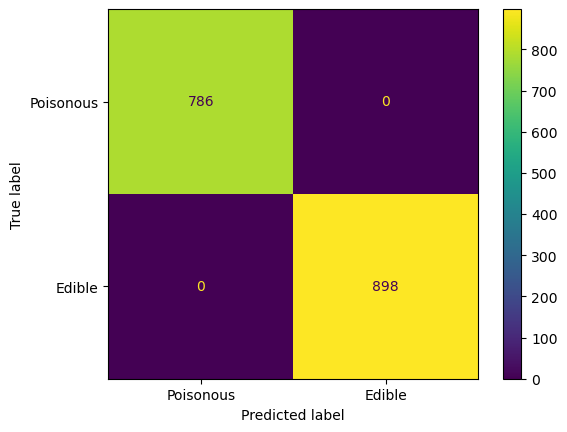

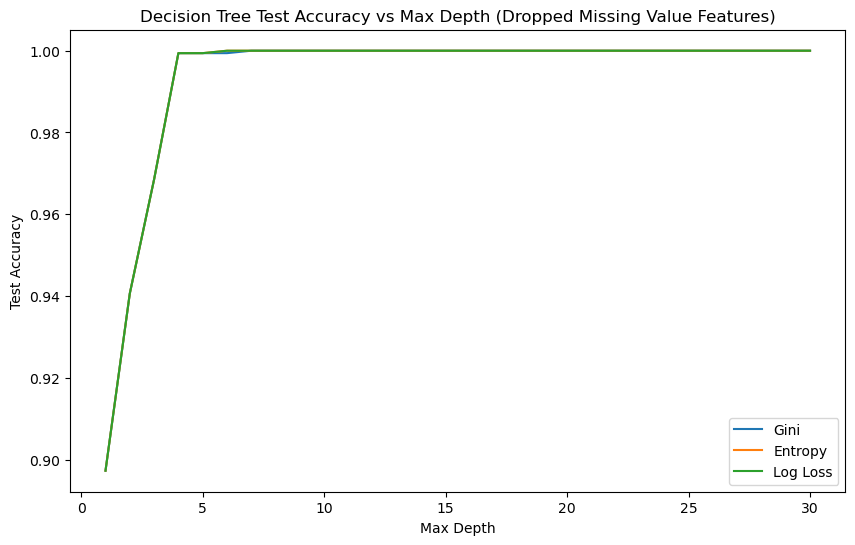

In [40]:
print("Total number of decision trees trained", decision_tree_results.shape[0])
print("Number of decision trees with accuracy 1: ", decision_tree_results[decision_tree_results["Test Accuracy"] == 1].shape[0])
display(decision_tree_results.head(10))

# Comparison for the dataset with dropped missing value features
dt_results_gini_dropped = decision_tree_results[(decision_tree_results["Notes"] == "Criterion: gini") & (decision_tree_results["Preprocessing"] == "dropped")]
dt_results_entropy_dropped = decision_tree_results[(decision_tree_results["Notes"] == "Criterion: entropy") & (decision_tree_results["Preprocessing"] == "dropped")]
dt_results_log_loss_dropped = decision_tree_results[(decision_tree_results["Notes"] == "Criterion: log_loss") & (decision_tree_results["Preprocessing"] == "dropped")]

dt_results_gini_dropped.loc[:, "Hyperparameters"] = dt_results_gini_dropped["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))
dt_results_entropy_dropped.loc[:, "Hyperparameters"] = dt_results_entropy_dropped["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))
dt_results_log_loss_dropped.loc[:, "Hyperparameters"] = dt_results_log_loss_dropped["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))

dt_results_gini_dropped = dt_results_gini_dropped.sort_values("Hyperparameters")
dt_results_entropy_dropped = dt_results_entropy_dropped.sort_values("Hyperparameters")
dt_results_log_loss_dropped = dt_results_log_loss_dropped.sort_values("Hyperparameters")


# Plot the model accuracy over max depth for each criterion and dataset 
pyplot.figure(figsize=(10, 6))
pyplot.plot(dt_results_gini_dropped["Hyperparameters"], dt_results_gini_dropped["Test Accuracy"], label="Gini")
pyplot.plot(dt_results_entropy_dropped["Hyperparameters"], dt_results_entropy_dropped["Test Accuracy"], label="Entropy")
pyplot.plot(dt_results_log_loss_dropped["Hyperparameters"], dt_results_log_loss_dropped["Test Accuracy"], label="Log Loss")
pyplot.title("Decision Tree Test Accuracy vs Max Depth (Dropped Missing Value Features)")
pyplot.xlabel("Max Depth")
pyplot.ylabel("Test Accuracy")
pyplot.legend()
pyplot.show()


# Comparison for the dataset with filled missing value features
dt_results_gini_filled = decision_tree_results[(decision_tree_results["Notes"] == "Criterion: gini") & (decision_tree_results["Preprocessing"] == "filled")]
dt_results_entropy_filled = decision_tree_results[(decision_tree_results["Notes"] == "Criterion: entropy") & (decision_tree_results["Preprocessing"] == "filled")]
dt_results_log_loss_filled = decision_tree_results[(decision_tree_results["Notes"] == "Criterion: log_loss") & (decision_tree_results["Preprocessing"] == "filled")]

dt_results_gini_filled.loc[:, "Hyperparameters"] = dt_results_gini_filled["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))
dt_results_entropy_filled.loc[:, "Hyperparameters"] = dt_results_entropy_filled["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))
dt_results_log_loss_filled.loc[:, "Hyperparameters"] = dt_results_log_loss_filled["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))

dt_results_gini_filled = dt_results_gini_filled.sort_values("Hyperparameters")
dt_results_entropy_filled = dt_results_entropy_filled.sort_values("Hyperparameters")
dt_results_log_loss_filled = dt_results_log_loss_filled.sort_values("Hyperparameters")

# Plot the model accuracy over max depth for each criterion and dataset
pyplot.figure(figsize=(10, 6))
pyplot.plot(dt_results_gini_filled["Hyperparameters"], dt_results_gini_filled["Test Accuracy"], label="Gini")
pyplot.plot(dt_results_entropy_filled["Hyperparameters"], dt_results_entropy_filled["Test Accuracy"], label="Entropy")
pyplot.plot(dt_results_log_loss_filled["Hyperparameters"], dt_results_log_loss_filled["Test Accuracy"], label="Log Loss")
pyplot.title("Decision Tree Test Accuracy vs Max Depth (Filled Missing Value Features)")
pyplot.xlabel("Max Depth")
pyplot.ylabel("Test Accuracy")
pyplot.legend()


Out of 180 decision trees trained, 148 trees had an accuracy of 1. When the trees had a max depth greater than about 6, the accuracy of the models was 1. Comparing the different criterion for training the models, there was no significant difference between each of the three criterion on the dataset with dropped missing value features. On the other dataset with filled missing value features, on lower max depth values, the Gini criterion had a higher accuracy than the other two criterion and learned the data slightly faster.

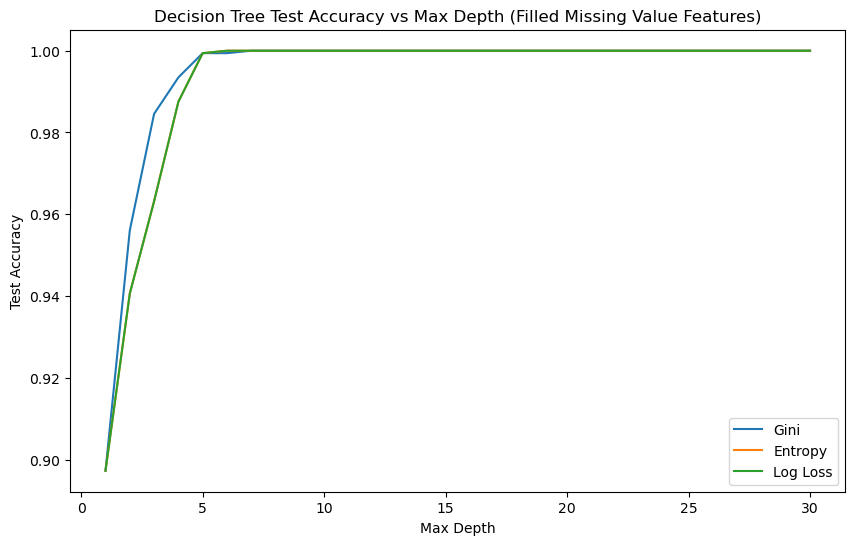

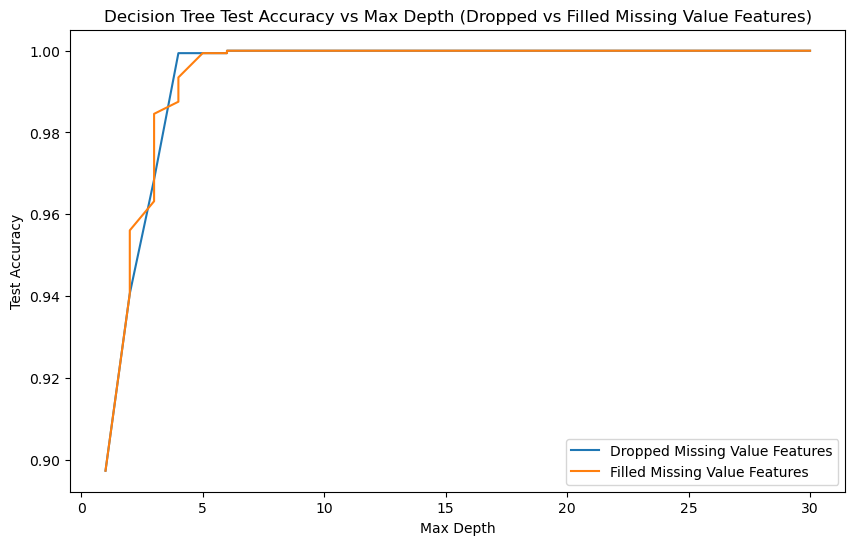

In [41]:
# Comparing the accuracies of the two preproccessing methods
dt_results_dropped = decision_tree_results[(decision_tree_results["Preprocessing"] == "dropped") & (decision_tree_results["Notes"] != "Baseline Model")]
dt_results_filled = decision_tree_results[(decision_tree_results["Preprocessing"] == "filled") & (decision_tree_results["Notes"] != "Baseline Model")]

dt_results_dropped.loc[:, "Hyperparameters"] = dt_results_dropped["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))
dt_results_filled.loc[:, "Hyperparameters"] = dt_results_filled["Hyperparameters"].apply(lambda x: int(x.split("=")[1]))

dt_results_dropped = dt_results_dropped.sort_values("Hyperparameters")
dt_results_filled = dt_results_filled.sort_values("Hyperparameters")


# Plot the model accuracy compared with the two different preproccessing methods
pyplot.figure(figsize=(10, 6))
pyplot.plot(dt_results_dropped["Hyperparameters"], dt_results_dropped["Test Accuracy"], label="Dropped Missing Value Features")
pyplot.plot(dt_results_filled["Hyperparameters"], dt_results_filled["Test Accuracy"], label="Filled Missing Value Features")
pyplot.title("Decision Tree Test Accuracy vs Max Depth (Dropped vs Filled Missing Value Features)")
pyplot.xlabel("Max Depth")
pyplot.ylabel("Test Accuracy")
pyplot.legend()
pyplot.show()



Comparing the two accuracies of the different preprocessing methods, there was not much difference between the two. The filled missing value dataset was slightly better at some max depth values, and slightly worse at others, but overall the two preprocessing methods had very similar accuracies across all max depth values, and there is no clear advantage shown for either preprocessing method based on this dataset.

#### Decision Tree Visualization

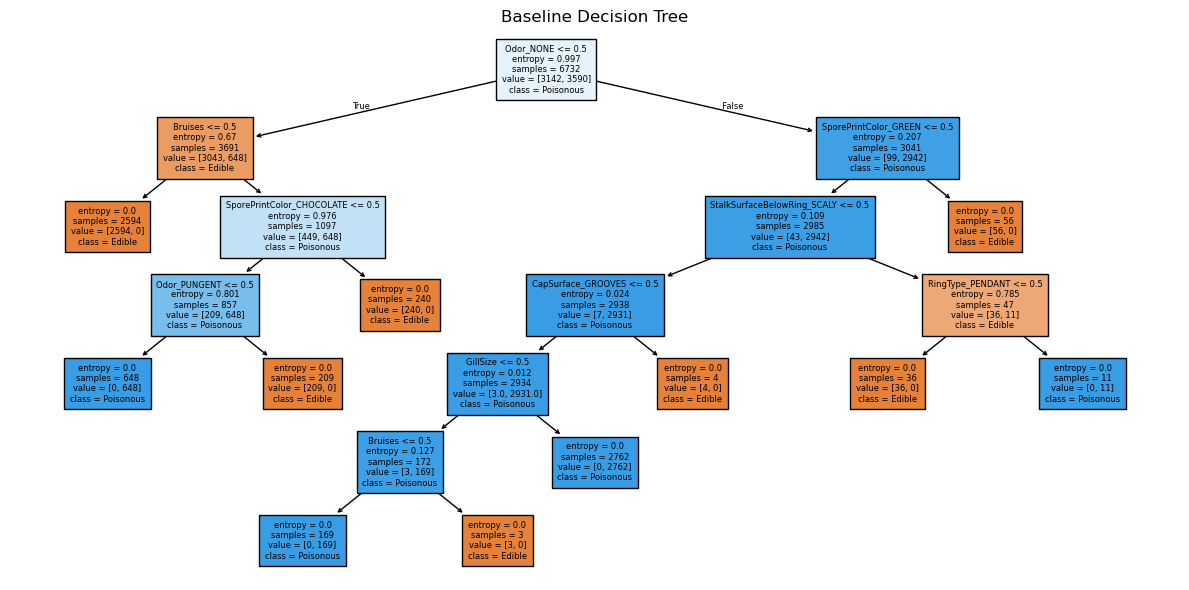

In [42]:
from sklearn.tree import plot_tree


features = droppedfeatures_train.columns.tolist()

# Visualize the baseline dt model
pyplot.figure(figsize=(12, 6))
plot_tree(baseline_dt,feature_names=features, class_names=['Edible', 'Poisonous'], filled=True, fontsize=6)
pyplot.title('Baseline Decision Tree')
pyplot.tight_layout()
pyplot.show()

0.8972684085510689


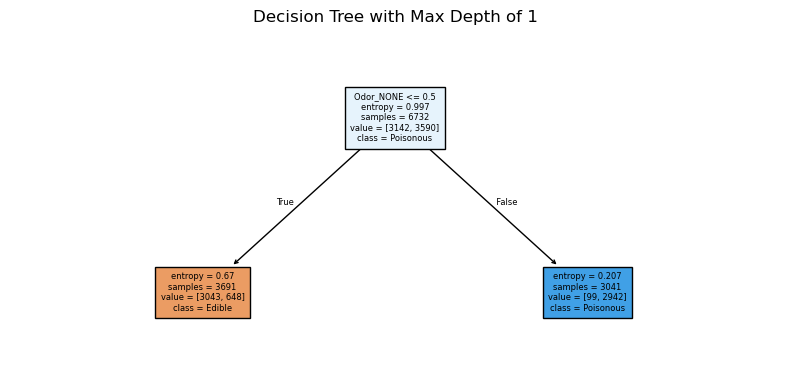

In [43]:
# Visualize the decision tree with max depth of 1
dt_1 = DecisionTreeClassifier(criterion="entropy", random_state=42, max_depth=1).fit(droppedfeatures_train, droppedlabels_train)
print(dt_1.score(droppedfeatures_test, droppedlabels_test))

pyplot.figure(figsize=(8, 4))
plot_tree(dt_1,feature_names=features, class_names=['Edible', 'Poisonous'], filled=True, fontsize=6)
pyplot.title('Decision Tree with Max Depth of 1')
pyplot.tight_layout()
pyplot.show()

The only real difference in accuracies between the different models was when the max depth was very low. Even when the max depth was only 1, the model still had an accuracy of around 0.9 which shows how important that one features is for determining the edibility of a mushroom. over 90% of the mushrooms in the dataset can be correctly classified as edible or poisonous based on only if they an odor or not.

Because many of the models had an accuracy of 1, there is not really one best performing model to visualize, so we will use the baselinde model for the visualization. This shows how the most important features for determining the edibility of a mushroom are the odor, bruizes, and spore print color. Additionally the model is fairly simple and easy to interpret, with a depth of only 7. Interpretability is important for this problem because of the real world dangers of misclassifying a poisonous mushroom as edible, so being able to understand how the model is making its decisions is important.

##### Limitations
Because most of the models were able to reach a perfect accuracy when predicting this dataset, there weren't many differences between the models using diffferent parameters or preproccessing strategies, which makes it diffficult to compare how these affect model performance. 

## Random Forest

For the Random Forest section, we will use **one single preprocessing pipeline** and make the model itself more sophisticated.
### Workflow:
1. train a baseline model
2. Run RandomizedSearchCV for inital hyperparameter search
3. Run GridSearchCV to refine the search near the strongest settings
4. Evaluate using N-fold CV
5. Inspect
### Why this approach?
Random Forest is a strong choice for this dataset because:
- the data is mostly categorical and has already been encoded numerically
- Random Forest handles nonlinear feature interactions well

Because the mushroom dataset is known to be highly structured, it is possible for tree-based models to achieve extremely high performance. For that reason, the goal of tuning here is not only to improve the score, but also to check whether performance remains stable across different hyperparameter settings.


In [44]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

rf_X_train = filledfeatures_train.copy()
rf_X_test = filledfeatures_test.copy()

rf_y_train = pd.Series(filledlabels_train).astype(int)
rf_y_test = pd.Series(filledlabels_test).astype(int)
rf_preprocessing_name = "Filled StalkRoot"

baseline_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)
#Evaluate the baseline model and add results to the results DataFrame
baseline_metrics, baseline_y_pred = evaluate_model(
    baseline_rf,
    rf_X_train, rf_X_test,
    rf_y_train, rf_y_test
)
results = add_result(
    results,
    model_name="Random Forest (Baseline)",
    preprocessing_name=rf_preprocessing_name,
    hyperparameters=baseline_rf.get_params(),
    cv_mean=baseline_metrics["CV Mean"],
    cv_std=baseline_metrics["CV Std"],
    test_accuracy=baseline_metrics["Test Accuracy"],
    test_precision=baseline_metrics["Test Precision"],
    test_recall=baseline_metrics["Test Recall"],
    test_f1=baseline_metrics["Test F1"],
    training_time=baseline_metrics["Training Time (s)"],
    notes="Default Random Forest used as the baseline."
)

print("Baseline Results:")
print(baseline_metrics)

#RandomizedSearchCV
random_param_dist = {
    "n_estimators": [100, 200, 300, 500], #Exploring a range of values for n_estimators to find a good balance between performance and training time, given the dataset size and complexity
    "max_depth": [None, 10, 20, 30, 40], #None is included to allow for fully grown trees, but we also want to explore some reasonable depth limits given the dataset size and complexity
    "min_samples_split": [2, 5, 10], #Focusing on smaller values for min_samples_split since larger values would likely underfit given the dataset size and complexity
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=random_param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy", #using accuracy for now
    random_state=42,
    n_jobs=-1
)

random_start = time.time()
random_search.fit(rf_X_train, rf_y_train)
random_time = time.time() - random_start

random_best_rf = random_search.best_estimator_
random_y_pred = random_best_rf.predict(rf_X_test)

random_metrics = {
    "CV Mean": random_search.best_score_,
    "CV Std": np.nan,
    "Test Accuracy": accuracy_score(rf_y_test, random_y_pred),
    "Test Precision": precision_score(rf_y_test, random_y_pred),
    "Test Recall": recall_score(rf_y_test, random_y_pred),
    "Test F1": f1_score(rf_y_test, random_y_pred),
    "Training Time (s)": random_time
}

results = add_result(
    results,
    model_name="Random Forest (RandomizedSearchCV)",
    preprocessing_name=rf_preprocessing_name,
    hyperparameters=random_search.best_params_,
    cv_mean=random_metrics["CV Mean"],
    cv_std=random_metrics["CV Std"],
    test_accuracy=random_metrics["Test Accuracy"],
    test_precision=random_metrics["Test Precision"],
    test_recall=random_metrics["Test Recall"],
    test_f1=random_metrics["Test F1"],
    training_time=random_metrics["Training Time (s)"],
    notes="Broad hyperparameter search using RandomizedSearchCV."
)

print("\nBest RandomizedSearchCV Parameters:")
print(random_search.best_params_)
print("Best RandomizedSearchCV CV Score:", random_search.best_score_)
print("RandomizedSearchCV Test Metrics:")
print(random_metrics)

#Finetuning with GridSearchCV
random_best_params = random_search.best_params_


#Helper function to get a focused range of candidates around the best value
def around_center(value, candidates):
    if value not in candidates:
        return candidates
    idx = candidates.index(value)
    left = max(0, idx - 1)
    right = min(len(candidates), idx + 2)
    return candidates[left:right]

n_estimator_candidates = sorted(set(around_center(random_best_params["n_estimators"], [100, 200, 300, 500])))
max_depth_candidates = sorted(set(around_center(random_best_params["max_depth"], [10, 20, 30, 40]) if random_best_params["max_depth"] is not None else [None, 20, 30]))
min_split_candidates = sorted(set(around_center(random_best_params["min_samples_split"], [2, 5, 10])))
min_leaf_candidates = sorted(set(around_center(random_best_params["min_samples_leaf"], [1, 2, 4])))

grid_param_grid = {
    "n_estimators": n_estimator_candidates,
    "max_depth": max_depth_candidates, #None is included if it was the best value, otherwise we focus around the best non-None value
    "min_samples_split": min_split_candidates,#Same thing here, focus around the best value from RandomizedSearchCV
    "min_samples_leaf": min_leaf_candidates,
    "max_features": [random_best_params["max_features"]],
    "bootstrap": [random_best_params["bootstrap"]]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=grid_param_grid, 
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_start = time.time()
grid_search.fit(rf_X_train, rf_y_train)
grid_time = time.time() - grid_start

best_rf = grid_search.best_estimator_
best_y_pred = best_rf.predict(rf_X_test)

best_rf_metrics = {
    "CV Mean": grid_search.best_score_,
    "CV Std": np.nan,
    "Test Accuracy": accuracy_score(rf_y_test, best_y_pred),
    "Test Precision": precision_score(rf_y_test, best_y_pred),
    "Test Recall": recall_score(rf_y_test, best_y_pred),
    "Test F1": f1_score(rf_y_test, best_y_pred),
    "Training Time (s)": grid_time
}

results = add_result(
    results,
    model_name="Random Forest (Focused GridSearchCV)",
    preprocessing_name=rf_preprocessing_name,
    hyperparameters=grid_search.best_params_,
    cv_mean=best_rf_metrics["CV Mean"],
    cv_std=best_rf_metrics["CV Std"],
    test_accuracy=best_rf_metrics["Test Accuracy"],
    test_precision=best_rf_metrics["Test Precision"],
    test_recall=best_rf_metrics["Test Recall"],
    test_f1=best_rf_metrics["Test F1"],
    training_time=best_rf_metrics["Training Time (s)"],
    notes="Focused GridSearchCV refinement around the strongest randomized-search settings."
)

best_y_test = rf_y_test
best_feature_names = rf_X_train.columns

print("\nBestGridSearchCV Parameters:")
print(grid_search.best_params_)
print("Best GridSearchCV CV Score:", grid_search.best_score_)
print("GridSearchCV Test Metrics:")
print(best_rf_metrics)


Baseline Results:
{'CV Mean': 1.0, 'CV Std': 0.0, 'Test Accuracy': 1.0, 'Test Precision': 1.0, 'Test Recall': 1.0, 'Test F1': 1.0, 'Training Time (s)': 2.1893868446350098}

Best RandomizedSearchCV Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 30, 'bootstrap': True}
Best RandomizedSearchCV CV Score: 1.0
RandomizedSearchCV Test Metrics:
{'CV Mean': 1.0, 'CV Std': nan, 'Test Accuracy': 1.0, 'Test Precision': 1.0, 'Test Recall': 1.0, 'Test F1': 1.0, 'Training Time (s)': 33.52683997154236}

BestGridSearchCV Parameters:
{'bootstrap': True, 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best GridSearchCV CV Score: 1.0
GridSearchCV Test Metrics:
{'CV Mean': 1.0, 'CV Std': nan, 'Test Accuracy': 1.0, 'Test Precision': 1.0, 'Test Recall': 1.0, 'Test F1': 1.0, 'Training Time (s)': 35.57172656059265}


### Random Forest Results

The table below compares the three stages of the same Random Forest pipeline:

1. **Baseline model** — the default Random Forest used as a starting point.
2. **RandomizedSearchCV** — a broader search across many possible hyperparameter combinations.
3. **Focused GridSearchCV** — a smaller refinement search centered around the strongest randomized-search result.


In this notebook, all three stages achieved the same perfect classification performance. That means the baseline model had already reached the performance ceiling on this dataset. Even though tuning did not increase accuracy, it still added value by showing that the model's performance was **stable and robust** across different settings rather than depending on one lucky parameter choice.


In [45]:
rf_results = results[results["Model"].str.contains("Random Forest")].copy()
rf_results = rf_results.sort_values(
    by=["Test Accuracy", "CV Mean", "Test F1"],
    ascending=False
).reset_index(drop=True)

rf_results

,Model,Preprocessing,Hyperparameters,CV Mean,CV Std,...,Test Precision,Test Recall,Test F1,Training Time (s),Notes
0,Random Forest (B...,Filled StalkRoot,{'bootstrap': Tr...,1.0,0.0,...,1.0,1.0,1.0,2.189387,Default Random F...
1,Random Forest (R...,Filled StalkRoot,{'n_estimators':...,1.0,NaN,...,1.0,1.0,1.0,33.526840,Broad hyperparam...
2,Random Forest (F...,Filled StalkRoot,{'bootstrap': Tr...,1.0,NaN,...,1.0,1.0,1.0,35.571727,Focused GridSear...


### Interpreting the Perfect Scores

A score of **1.0** across cross-validation and the test set can look suspicious at first, so it is important to interpret it carefully.

This result does not automatically means overfitting. Especially in this case:
- the cross-validation mean is also 1.0,
- the cross-validation standard deviation is 0.0,
- the held-out test set accuracy, precision, recall, and F1-score are also 1.0.

These results suggest that the mushroom dataset is **highly separable** for tree-based methods, not that the model is simply memorizing the training data.

This result also does **not strongly suggest leakage**. Although some preprocessing steps were done before splitting, those steps were label independent transformations such as one-hot encoding and missing-value handling. Since the model also performs perfectly under cross-validation on the training set and on the separate test set, there is no clear evidence that leakage is driving the result.

### Final Tuned Random Forest Model
Now we will inspect that final tuned model in more detail using:
1. the best hyperparameters
2. the classification report
3. the confusion matrix
4. feature importances


This step moves beyond overall accuracy and helps show **how** the model is making its decisions. Since the model achieved perfect scores, these diagnostics mainly serve as validation and interpretation rather than error analysis.


In [46]:
final_rf_summary = pd.DataFrame([{
    "Preprocessing": rf_preprocessing_name,
    "Best CV Mean": grid_search.best_score_,
    "Test Accuracy": best_rf_metrics["Test Accuracy"],
    "Test Precision": best_rf_metrics["Test Precision"],
    "Test Recall": best_rf_metrics["Test Recall"],
    "Test F1": best_rf_metrics["Test F1"],
    "Best Params": grid_search.best_params_
}])

final_rf_summary


print("Final Classification Report:")
print(classification_report(best_y_test, best_y_pred, target_names=["Poisonous", "Edible"]))


Final Classification Report:
              precision    recall  f1-score   support

   Poisonous       1.00      1.00      1.00       786
      Edible       1.00      1.00      1.00       898

    accuracy                           1.00      1684
   macro avg       1.00      1.00      1.00      1684
weighted avg       1.00      1.00      1.00      1684



### Confusion Matrix and Feature Importance Interpretation

The confusion matrix shows whether the model made any mistakes on the held-out test set. In this notebook, the matrix should show all predictions on the diagonal and zeros elsewhere, which confirms that every test sample was classified correctly.

The feature-importance table highlights which encoded mushroom characteristics contributed most to the model's decisions. These values do **not** prove causation, but they do help identify which attributes were most useful for separating edible from poisonous mushrooms in this dataset.

In [47]:
# Confusion matrix
cm = confusion_matrix(best_y_test, best_y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Poisonous", "Actual Edible"],
    columns=["Predicted Poisonous", "Predicted Edible"]
)

print("Confusion Matrix:")
display(cm_df)


# Feature importances
feature_importances = pd.DataFrame({
    "Feature": best_feature_names,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("Top 15 Most Important Features:")
display(feature_importances.head(15))

print("Train Accuracy:", best_rf.score(rf_X_train, rf_y_train))
print("Test Accuracy:", best_rf.score(rf_X_test, rf_y_test))

Confusion Matrix:


,Predicted Poisonous,Predicted Edible
Actual Poisonous,786,0
Actual Edible,0,898


Top 15 Most Important Features:


,Feature,Importance
31,Odor_NONE,0.623452
51,StalkRoot_CLUB,0.151887
60,StalkSurfaceBelo...,0.052230
53,StalkRoot_ROOTED,0.037152
94,SporePrintColor_...,0.032326
0,Bruises,0.022825
26,Odor_ANISE,0.016975
25,Odor_ALMOND,0.016717
52,StalkRoot_EQUAL,0.004883
96,SporePrintColor_...,0.004419


Train Accuracy: 1.0
Test Accuracy: 1.0


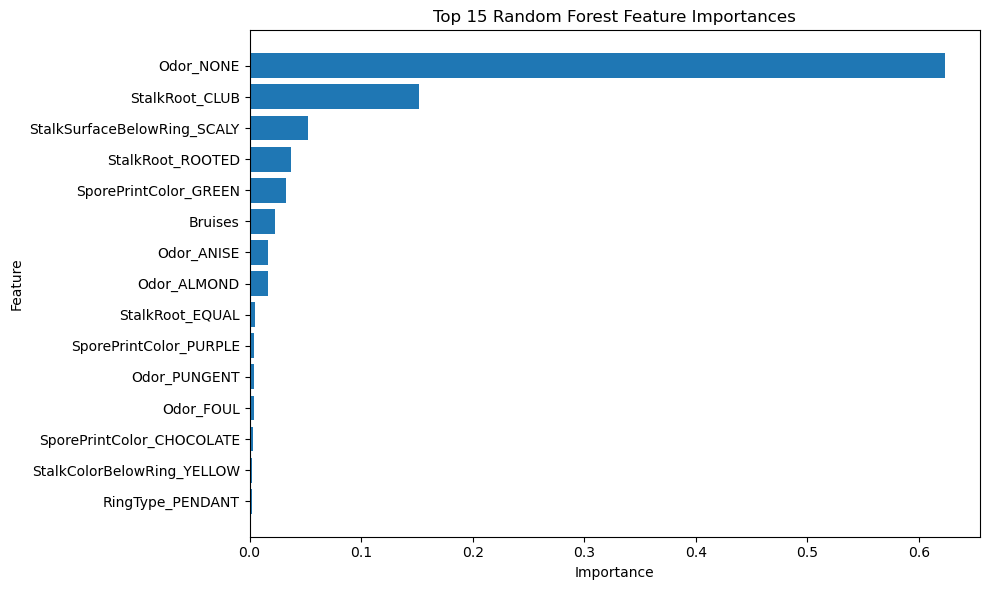

OOB Score: 1.0


In [48]:
# Plot top 15 feature importances
top_n = 15
top_features = feature_importances.head(top_n).sort_values("Importance", ascending=True)

pyplot.figure(figsize=(10, 6))
pyplot.barh(top_features["Feature"], top_features["Importance"])
pyplot.xlabel("Importance")
pyplot.ylabel("Feature")
pyplot.title("Top 15 Random Forest Feature Importances")
pyplot.tight_layout()
pyplot.show()

oob_rf = RandomForestClassifier(
    **grid_search.best_params_,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

oob_rf.fit(rf_X_train, rf_y_train)
print("OOB Score:", oob_rf.oob_score_)

To further evaluate whether the Random Forest model is generalizing well, an additional out-of-bag (OOB) score is computed.

Random Forest trains each tree on a bootstrap sample of the training data, which means some training examples are left out of each tree’s sample. These left-out examples are called out-of-bag samples. After training, the model can make predictions on those unseen samples and combine them into an internal validation score.

This is useful because it provides another estimate of model performance without requiring a separate validation split. In other words, the OOB score acts like an extra built-in generalization check for Random Forest.

## Random Forest Feature Ablation Study: Removing `Odor`

Because the original Random Forest runs all reached perfect performance, a useful next step is to test whether that performance depends too heavily on one especially informative feature. In mushroom classification, **odor** is often one of the strongest predictors of edibility, so we remove it on purpose and rerun the same Random Forest configurations.

### Goal of this section
- keep the same train/test split
- remove all `Odor`-related columns from a separate copy of the encoded data
- rerun the same three Random Forest configurations used earlier
- compare original-data performance against odor-ablated performance

This is not meant to improve the model. Instead, it helps show whether Random Forest is still strong when one major predictor is removed.

In [49]:
# Identify all one-hot encoded odor columns and create an odor-ablated copy
odor_columns = [col for col in rf_X_train.columns if col == "Odor" or col.startswith("Odor_")]

print("Odor-related columns found:", len(odor_columns))
print(odor_columns)

rf_no_odor_X_train = rf_X_train.drop(columns=odor_columns).copy()
rf_no_odor_X_test = rf_X_test.drop(columns=odor_columns).copy()

print("Original training shape:", rf_X_train.shape)
print("Original testing shape:", rf_X_test.shape)
print("No-odor training shape:", rf_no_odor_X_train.shape)
print("No-odor testing shape:", rf_no_odor_X_test.shape)


Odor-related columns found: 9
['Odor_ALMOND', 'Odor_ANISE', 'Odor_CREOSOTE', 'Odor_FISHY', 'Odor_FOUL', 'Odor_MUSTY', 'Odor_NONE', 'Odor_PUNGENT', 'Odor_SPICY']
Original training shape: (6732, 112)
Original testing shape: (1684, 112)
No-odor training shape: (6732, 103)
No-odor testing shape: (1684, 103)


### Random Forest configurations used in the ablation study

To keep the comparison fair, we reuse the same Random Forest workflow as before:

- **Baseline Random Forest** using default settings
- **RandomizedSearchCV Random Forest** using broad hyperparameter search
- **Focused GridSearchCV Random Forest** using a narrower refinement search

The only difference is whether the model sees all encoded features or the same data with all odor-related columns removed.


In [50]:
def build_rf_configs(X_train, y_train):
    configs = []

    baseline_model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )
    configs.append(("Random Forest (Baseline)", baseline_model, None, "Default Random Forest used as the baseline."))

    random_param_dist_ablation = {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [None, 10, 20, 30, 40],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", None],
        "bootstrap": [True, False]
    }

    random_search_ablation = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_distributions=random_param_dist_ablation,
        n_iter=20,
        cv=5,
        scoring="accuracy",
        random_state=42,
        n_jobs=-1
    )
    random_search_ablation.fit(X_train, y_train)
    configs.append((
        "Random Forest (RandomizedSearchCV)",
        random_search_ablation.best_estimator_,
        random_search_ablation.best_params_,
        "Broad hyperparameter search using RandomizedSearchCV."
    ))

    random_best_params_ablation = random_search_ablation.best_params_

    def around_center(value, candidates):
        if value not in candidates:
            return candidates
        idx = candidates.index(value)
        left = max(0, idx - 1)
        right = min(len(candidates), idx + 2)
        return candidates[left:right]

    n_estimator_candidates = sorted(set(around_center(random_best_params_ablation["n_estimators"], [100, 200, 300, 500])))
    max_depth_candidates = sorted(set(around_center(random_best_params_ablation["max_depth"], [10, 20, 30, 40]) if random_best_params_ablation["max_depth"] is not None else [None, 20, 30]))
    min_split_candidates = sorted(set(around_center(random_best_params_ablation["min_samples_split"], [2, 5, 10])))
    min_leaf_candidates = sorted(set(around_center(random_best_params_ablation["min_samples_leaf"], [1, 2, 4])))

    grid_param_grid_ablation = {
        "n_estimators": n_estimator_candidates,
        "max_depth": max_depth_candidates,
        "min_samples_split": min_split_candidates,
        "min_samples_leaf": min_leaf_candidates,
        "max_features": [random_best_params_ablation["max_features"]],
        "bootstrap": [random_best_params_ablation["bootstrap"]]
    }

    grid_search_ablation = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid=grid_param_grid_ablation,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    grid_search_ablation.fit(X_train, y_train)
    configs.append((
        "Random Forest (Focused GridSearchCV)",
        grid_search_ablation.best_estimator_,
        grid_search_ablation.best_params_,
        "Focused GridSearchCV refinement around the strongest randomized-search settings."
    ))

    return configs


def run_rf_config_experiment(config_name, model, X_train, X_test, y_train, y_test, feature_set_name, hyperparameters, notes):
    metrics, y_pred = evaluate_model(model, X_train, X_test, y_train, y_test)
    return {
        "Model": config_name,
        "Feature Set": feature_set_name,
        "Hyperparameters": hyperparameters if hyperparameters is not None else model.get_params(),
        "CV Mean": metrics["CV Mean"],
        "CV Std": metrics["CV Std"],
        "Test Accuracy": metrics["Test Accuracy"],
        "Test Precision": metrics["Test Precision"],
        "Test Recall": metrics["Test Recall"],
        "Test F1": metrics["Test F1"],
        "Training Time (s)": metrics["Training Time (s)"],
        "Notes": notes
    }

rf_ablation_rows = []

for feature_set_name, X_train_curr, X_test_curr in [
    ("All Features", rf_X_train, rf_X_test),
    ("Without Odor", rf_no_odor_X_train, rf_no_odor_X_test),
]:
    rf_configs = build_rf_configs(X_train_curr, rf_y_train)
    for config_name, model, hyperparameters, notes in rf_configs:
        rf_ablation_rows.append(
            run_rf_config_experiment(
                config_name,
                model,
                X_train_curr,
                X_test_curr,
                rf_y_train,
                rf_y_test,
                feature_set_name,
                hyperparameters,
                notes
            )
        )

rf_ablation_results = pd.DataFrame(rf_ablation_rows)
rf_ablation_results


,Model,Feature Set,Hyperparameters,CV Mean,CV Std,...,Test Precision,Test Recall,Test F1,Training Time (s),Notes
0,Random Forest (B...,All Features,{'bootstrap': Tr...,1.0,0.0,...,1.0,1.0,1.0,1.502141,Default Random F...
1,Random Forest (R...,All Features,{'n_estimators':...,1.0,0.0,...,1.0,1.0,1.0,5.803425,Broad hyperparam...
2,Random Forest (F...,All Features,{'bootstrap': Tr...,1.0,0.0,...,1.0,1.0,1.0,3.691650,Focused GridSear...
3,Random Forest (B...,Without Odor,{'bootstrap': Tr...,1.0,0.0,...,1.0,1.0,1.0,1.444585,Default Random F...
4,Random Forest (R...,Without Odor,{'n_estimators':...,1.0,0.0,...,1.0,1.0,1.0,5.456944,Broad hyperparam...
5,Random Forest (F...,Without Odor,{'bootstrap': Tr...,1.0,0.0,...,1.0,1.0,1.0,3.504318,Focused GridSear...


### Interpreting the Random Forest ablation results

This table compares the same Random Forest workflow under two feature conditions:

All Features = the full encoded dataset
Without Odor = the same dataset after removing all odor-related columns

In this project, the most important takeaway is not whether performance improved, but whether it changed after ablation.

Key interpretation ideas:

If performance remains at or near 1.0 after removing odor, then Random Forest is not relying on odor alone. This suggests that the dataset contains substantial redundant predictive information in other features.
If performance drops noticeably after removing odor, then odor was a major contributor to the model’s predictive power.
If baseline and tuned configurations all remain strong after ablation, then the dataset is highly separable for Random Forest across multiple parameter settings.
If tuning does not improve performance over the baseline, that indicates the baseline model had already reached the dataset’s performance ceiling rather than that tuning was useless.

In [51]:
rf_ablation_pivot = rf_ablation_results.pivot(index="Model", columns="Feature Set", values="Test Accuracy")
rf_ablation_pivot["Accuracy Drop"] = rf_ablation_pivot["All Features"] - rf_ablation_pivot["Without Odor"]
rf_ablation_pivot = rf_ablation_pivot.reset_index()

rf_ablation_pivot


Feature Set,Model,All Features,Without Odor,Accuracy Drop
0,Random Forest (B...,1.0,1.0,0.0
1,Random Forest (F...,1.0,1.0,0.0
2,Random Forest (R...,1.0,1.0,0.0


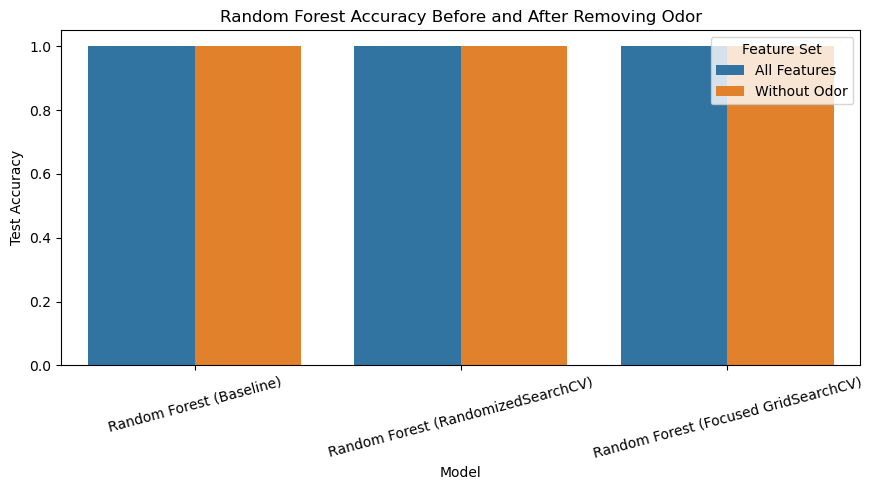

In [52]:
# Visual comparison of test accuracy before and after odor removal for each Random Forest configuration
plot_df = rf_ablation_results[["Model", "Feature Set", "Test Accuracy"]].copy()

pyplot.figure(figsize=(9, 5))
seaborn.barplot(data=plot_df, x="Model", y="Test Accuracy", hue="Feature Set")
pyplot.title("Random Forest Accuracy Before and After Removing Odor")
pyplot.xticks(rotation=15)
pyplot.ylim(0, 1.05)
pyplot.tight_layout()
pyplot.show()


### Ablation takeaway

This feature ablation analysis provides a stronger interpretation than accuracy alone. Since the original Random Forest models all achieved perfect performance, removing Odor helps test whether that performance depends heavily on one dominant feature or reflects broader patterns in the dataset.

In this notebook, performance remained perfect even after removing odor. That suggests the model is not relying on odor alone and that the dataset contains substantial redundant predictive information across multiple features.

This also helps address two earlier concerns:
- **Overfitting:** When performance remains consistently strong across cross-validation, the held-out test set, multiple Random Forest configurations, and the odor-removed dataset, that supports the idea that the dataset is highly separable rather than the model simply memorizing the training data.

- **Leakage concerns:** If perfect performance were driven mainly by one suspicious or overly informative feature, removing that feature would be expected to reduce performance. Since performance remained unchanged after removing odor, there is less reason to believe that the results are being driven by a single leaked signal.

### AdaBoost

#### Fit the model on the training data.

In [53]:
adadroppedfeatures_train = droppedfeatures_train.copy()
adadroppedlabels_train = droppedlabels_train.copy()
adadroppedfeatures_test = droppedfeatures_test.copy()
adadroppedlabels_test = droppedlabels_test.copy()

adafilledfeatures_train = filledfeatures_train.copy()
adafilledlabels_train = filledlabels_train.copy()
adafilledfeatures_test = filledfeatures_test.copy()
adafilledlabels_test = filledlabels_test.copy()

adaNrange = range(1,16)

adadroppedmodels = []
adafilledmodels = []
for N in adaNrange:
    adadroppedmodels.append(AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=N*10, random_state=42))
    adafilledmodels.append(AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=N*10, random_state=42))

#### Evaluate models with different n_estimators.

In [54]:
adadroppedevaluations = [0]
adafilledevaluations = [0]

adadroppedaccuracies = [0]
adafilledaccuracies = [0]
adadroppedprecisions = [0]
adafilledprecisions = [0]
adadroppedrecalls = [0]
adafilledrecalls = [0]
adadroppedtrainingtimes = [0]
adafilledtrainingtimes = [0]

for adadroppedmodel in adadroppedmodels:
    adadroppedevaluations.append(evaluate_model(adadroppedmodel, adadroppedfeatures_train, adadroppedfeatures_test, adadroppedlabels_train, adadroppedlabels_test))
    adadroppedaccuracies.append(adadroppedevaluations[-1]["Test Accuracy"])
    adadroppedprecisions.append(adadroppedevaluations[-1]["Test Precision"])
    adadroppedrecalls.append(adadroppedevaluations[-1]["Test Recall"])
    adadroppedtrainingtimes.append(adadroppedevaluations[-1]["Training Time (s)"])

for adafilledmodel in adafilledmodels:
    adafilledevaluations.append(evaluate_model(adafilledmodel, adafilledfeatures_train, adafilledfeatures_test, adafilledlabels_train, adafilledlabels_test))
    adafilledaccuracies.append(adafilledevaluations[-1]["Test Accuracy"])
    adafilledprecisions.append(adafilledevaluations[-1]["Test Precision"])
    adafilledrecalls.append(adafilledevaluations[-1]["Test Recall"])
    adafilledtrainingtimes.append(adafilledevaluations[-1]["Training Time (s)"])

TypeError: tuple indices must be integers or slices, not str

#### Plot the results.

In [ ]:
print("Dropped:")
bestadadroppedmodel = plot_adaboost_models_scores(adaNrange, adadroppedmodels, adadroppedaccuracies, adadroppedprecisions, adadroppedrecalls, adadroppedtrainingtimes)

print("Filled:")
bestadafilledmodel = plot_adaboost_models_scores(adaNrange, adafilledmodels, adafilledaccuracies, adafilledprecisions, adafilledrecalls, adafilledtrainingtimes)



print("Dropped:")
ConfusionMatrixDisplay.from_estimator(bestadadroppedmodel, adadroppedfeatures_test, adadroppedlabels_test)
pyplot.show()

print("Filled:")
ConfusionMatrixDisplay.from_estimator(bestadafilledmodel, adafilledfeatures_test, adafilledlabels_test)
pyplot.show()

#### Score the model on the test data.

In [ ]:
adadroppedscore_train = bestadadroppedmodel.score(adadroppedfeatures_train, adadroppedlabels_train)
adadroppedscore_test = bestadadroppedmodel.score(adadroppedfeatures_test, adadroppedlabels_test)

adafilledscore_train = bestadafilledmodel.score(adafilledfeatures_train, adafilledlabels_train)
adafilledscore_test = bestadafilledmodel.score(adafilledfeatures_test, adafilledlabels_test)

print("Dropped:")
print("Training Data Score:", adadroppedscore_train)
print("Test Data Score:", adadroppedscore_test)
print("")
print("Filled:")
print("Training Data Score:", adafilledscore_train)
print("Test Data Score:", adafilledscore_test)

#### Training Data Analysis

First, it is important to note what the most important metric for our model is; accuracy, of course, but more specifically, precision. It would be of little consequence for our algorithm to say a mushroom is poisonous if it is not, but it is of deadly import that our algorithm not classify a mushroom as edible, if it is not. Since the "edibility" feature here is represented as Poisonous/Edible = 0/1, that means that precision is our most important metric.

Based on the data above, no AdaBoost model with less than 100 iterations can be considered acceptable; even the one misclassification would be a significant issue. Going significantly above 100 would significantly increase training times, and without more data to train on, has no measurable benefit, though it could potentially cause the model to overfit; this is unlikely, given AdaBoost's propensity to not overfit, but nevertheless. I would recommend 100-110 iterations for one's own use.

The training time increases linearly, as one might expect, and there was literally no difference in performance between the models on the imputed dataset and the dropped dataset, implying the feature in question was so unimportant that the base model (stump decision tree) never split on StalkRoot at any point, rendering its inclusion in the dataset moot.

Finally, for the actual results, they are quite promising. Once we get past 100 iterations, the model scores perfectly on both the training and test datasets

### Removal Of Redundant Features

Because there are a large number of features never split on in the dataset, I thought it would be interesting to see what would happen if we tried removing these "redundant" features; theoretically, I believe doing so shouldn't change the results.

#### Initial Removal

In [ ]:
adafeatureoccurrences = {}
adaoccurredfeatures = ["Edibility"]

for estimator in bestadafilledmodel.estimators_:
    #print(dfnullsfilled.columns[estimator.tree_.feature[0]])
    adafeatureoccurrences.setdefault(estimator.tree_.feature[0], 0)
    adafeatureoccurrences[estimator.tree_.feature[0]] += 1

for key, value in adafeatureoccurrences.items():
    #print(f"{key}: {value}")
    adaoccurredfeatures.append(dfnullsfilled.columns[key])

adadfredundantsdropped = dfnullsfilled[adaoccurredfeatures]
print(adadfredundantsdropped.info())

Interestingly, while some of these split features (Bruises, GillSize, GillColor_BROWN, StalkSurfaceAboveRing_SMOOTH) are the ones noted as highly correlated in the heatmaps, most of them are not, and most of the expected features are also not present. Most notably, neither Odor_FOUL nor Odor_NONE appear here, despite being heavily correlated with mushroom edibility, though the other encodings of these "feature families" do appear, such as Odor_MUSTY.

#### Redundants Removed Training

In [ ]:
adaredundantsdroppedfeatures = adadfredundantsdropped.drop(columns=["Edibility"])
adaredundantsdroppedlabels = adadfredundantsdropped["Edibility"].astype(int)

adaredundantsdroppedfeatures_train, adaredundantsdroppedfeatures_test, adaredundantsdroppedlabels_train, adaredundantsdroppedlabels_test = train_test_split(
    adaredundantsdroppedfeatures,
    adaredundantsdroppedlabels,
    test_size=0.2,
    random_state=42,
    stratify=adaredundantsdroppedlabels
)



adaredundantsdroppedmodels = []
for N in adaNrange:
    adaredundantsdroppedmodels.append(AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=N*10, random_state=42))

adaredundantsdroppedevaluations = [0]

adaredundantsdroppedaccuracies = [0]
adaredundantsdroppedprecisions = [0]
adaredundantsdroppedrecalls = [0]
adaredundantsdroppedtrainingtimes = [0]

for adaredundantsdroppedmodel in adaredundantsdroppedmodels:
    adaredundantsdroppedevaluations.append(evaluate_model(adaredundantsdroppedmodel, adaredundantsdroppedfeatures_train, adaredundantsdroppedfeatures_test, adaredundantsdroppedlabels_train, adaredundantsdroppedlabels_test))
    adaredundantsdroppedaccuracies.append(adaredundantsdroppedevaluations[-1]["Test Accuracy"])
    adaredundantsdroppedprecisions.append(adaredundantsdroppedevaluations[-1]["Test Precision"])
    adaredundantsdroppedrecalls.append(adaredundantsdroppedevaluations[-1]["Test Recall"])
    adaredundantsdroppedtrainingtimes.append(adaredundantsdroppedevaluations[-1]["Training Time (s)"])


#### Plot Redundants Removed Data

In [ ]:
bestadaredundantsdroppedmodel = plot_adaboost_models_scores(adaNrange, adaredundantsdroppedmodels, adaredundantsdroppedaccuracies, adaredundantsdroppedprecisions, adaredundantsdroppedrecalls, adaredundantsdroppedtrainingtimes, [0.93, 1.00])

ConfusionMatrixDisplay.from_estimator(bestadaredundantsdroppedmodel, adaredundantsdroppedfeatures_test, adaredundantsdroppedlabels_test)
pyplot.show()



adaredundantsdroppedscore_train = adaredundantsdroppedmodel.score(adaredundantsdroppedfeatures_train, adaredundantsdroppedlabels_train)
adaredundantsdroppedscore_test = adaredundantsdroppedmodel.score(adaredundantsdroppedfeatures_test, adaredundantsdroppedlabels_test)

print("Training Data Score:", adaredundantsdroppedscore_train)
print("Test Data Score:", adaredundantsdroppedscore_test)
print("")

In [ ]:
adafeatureoccurrences = {}
adaoccurredfeatures = ["Edibility"]

for estimator in adaredundantsdroppedmodel.estimators_:
    #print(dfnullsfilled.columns[estimator.tree_.feature[0]])
    adafeatureoccurrences.setdefault(estimator.tree_.feature[0], 0)
    adafeatureoccurrences[estimator.tree_.feature[0]] += 1

for key, value in adafeatureoccurrences.items():
    #print(f"{key}: {value}")
    adaoccurredfeatures.append(dfnullsfilled.columns[key])

adadfredundantsdropped = dfnullsfilled[adaoccurredfeatures]
print(adadfredundantsdropped.info())

#### "Redundant" Feature Removal Analysis

Based on the results above, it appears that relatively decent results can be achieved by removing un-split-upon features, but my expectations were proven false in that 94-96% is a far cry from the original 100%; surprisingly, the AdaBoostClassifier chose different features to split on in the reduced dataset, and those which were previously split on immediately (such as Odor) have even managed to not appear whatsoever in the reduced model.

Based on theory of AdaBoost which I know, I can only think that there is some kind of random number generation happening which is affected by the number of features in the dataset; if so, that would actually imply that in the full dataset, there is a random number seed in existence that might cause the model to be less accurate, which implies that the original model may not maintain its 100% accuracy on all real mushroom datasets.

Due to the fatal nature of this particular use case, that is somewhat concerning; however, without additional data, it is only conjecture how inaccurate. It can only be stated that the reduced dataset model is most certainly unreliable, and should not be used for this task. However, if one really wanted to weigh the options, the best reduced dataset model would have to be with 12 iterations; it has maximum precision (most important!), and decent recall, combining into a strong overall accuracy. The main pro to using this reduced dataset is simply that it trains about 4x as quickly, which while not incredibally relevant to our use case, could be a strong argument in other scenarios, where 95% accuracy may be "good enough".

### CITATIONS

https://www.mecs-press.org/ijigsp/ijigsp-v11-n4/IJIGSP-V11-N4-5.pdf

Nusrat Jahan Pinky, S.M. Mohidul Islam, Rafia Sharmin Alice, " Edibility Detection of 
Mushroom Using Ensemble Methods", International Journal of Image, Graphics and Signal Processing(IJIGSP), Vol.11, 
No.4, pp. 55-62, 2019.DOI: 10.5815/ijigsp.2019.04.05

Effectively, a paper on the exact thing we are trying to do, even on the same (or similar, temporally speaking) dataset; very helpful to compare our own results against.